# Relic abundance calculations for Dark Photon DM

#### Libraries

In [65]:
# Library imports and params
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import glob
import csv

# Defining the fonts before plotting:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",  # Use monospace font
    "text.latex.preamble": r"\usepackage{courier}"  # Use Courier font
})
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'font.family': 'monospace',  # monospace font
    "text.latex.preamble": r"\usepackage{courier}",
    'font.size': 25,
    'axes.titlesize': 25,
    'axes.labelsize': 25,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 25,
    'figure.titlesize': 25,
})

## Scalar DM case

### Annihilation cross section

First, we consider the annihilation cross section for $\sigma_{\chi \chi \rightarrow f \bar{f}}$. We find after some Feynamnn diagrams and phase space integration that:

$$
\sigma v_{\text{rel}} = \frac{8 \pi}{3} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2} v^2_{\text{rel}} \sum_f K_f,
$$

where the $K_f$ kinematic factor for the fermion $f$ is defined as:
$$
K_f = Q_f^2 N_c^f \sqrt{1 - \frac{m_f^2}{m_\chi^2}} \left( 1 + \frac{1}{2} \frac{m_f^2}{m_\chi^2} \right) \Theta \left( m_\chi - m_f \right).
$$

Thermally averaging using the fact that $\left\langle v^2_{\text{rel}} \right\rangle = \frac{6}{x}$, we get:

$$
\left\langle \sigma v_{\text{rel}} \right\rangle = \frac{16 \pi}{x} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2}  \sum_f K_f.
$$

To treat the respective kinematic factors, we must take into account that for quarks, hadrons will be the relevant decay products at low energies. Thus, we will use the $R$ ratio as proxy for decays into hadrons:

$$
R(\sqrt{s}) = \frac{\sigma \left(e^+ e^- \rightarrow \text{hadrons} \right)}{\sigma \left(e^+ e^- \rightarrow \mu^+ \mu^- \right)},
$$

so the sum over kinematic factors becomes:

$$
\sum_f K_f \sim \sum_l K_l (m_\chi) + R(2 m_\chi) K_\mu(m_\chi).
$$

First we implement this cross section. The R ratio is taken from the PDG 2020 data set and interpolated linearly. 

In [66]:
mleptons = np.array([5.11e-4, 0.106, 1.777])  # Masses of leptons in GeV

def Kl(mchi, ml):
    """Phase-space factor for chi chi -> l+ l-, zero below threshold."""
    mchi = np.asarray(mchi, dtype=float)
    opench = mchi > ml
    r2 = np.where(opench, ml**2/np.where(opench, mchi, 1.0)**2, 0.0)
    return np.where(opench, np.sqrt(1 - r2)*(1 + r2/2), 0.0)

def sumKl(mchi):
    total = np.zeros_like(np.asarray(mchi, dtype=float))
    for ml in mleptons:
        total = total + Kl(mchi, ml)
    return total

def Kmu(mchi):
    """Muon phase-space factor, deliberately WITHOUT a threshold cut."""
    mchi = np.asarray(mchi, dtype=float)
    r2 = mleptons[1]**2/mchi**2
    return np.sqrt(1 - r2)*(1 + r2/2)

### Hadronic R ratio, R = sigma(e+e- -> hadrons)/sigma(e+e- -> mu+mu-), from
### the PDG compilation in data/rratio.dat (1400 points, 0.3-188.7 GeV).

def read_rratio(path="data/rratio.dat"):
    """Read the PDG R-ratio table -> (E_cm, R, dR)."""
    E, R, dR = [], [], []
    with open(path) as f:
        for line in f:
            if line.startswith("*") or not line.strip():
                continue
            try:
                ecm = float(line[0:10])
            except ValueError:
                continue                                  # continuation line
            if ecm <= 0.0:
                continue
            E.append(ecm)
            R.append(float(line[35:45]))
            dR.append(0.5*(abs(float(line[47:57])) + abs(float(line[58:68]))))
    return np.array(E), np.array(R), np.array(dR)

ecm_rratio, Rdata, dRdata = read_rratio()

# 70 energies are quoted by more than one experiment, but interp1d needs a
# strictly increasing x, so repeats are collapsed into a single inverse-
# variance weighted mean (the stat errors are all non-zero).
weights_R = 1.0/dRdata**2
ecm_R, index_R = np.unique(ecm_rratio, return_inverse=True)
R_R = (np.bincount(index_R, weights=weights_R*Rdata)
       / np.bincount(index_R, weights=weights_R))

# Linear in both E and R:
R_interp = interpolate.interp1d(ecm_R, R_R)

def R(sqrts):
    """Hadronic R ratio at sqrt(s), interpolated from the PDG table."""
    sqrts = np.asarray(sqrts, dtype=float)
    inside = sqrts >= ecm_R[0]
    return np.where(inside, R_interp(np.clip(sqrts, ecm_R[0], ecm_R[-1])), 0.0)

def RKmu(mchi):
    """Hadronic contribution R(2*mchi)*Kmu(mchi)."""
    mchi = np.asarray(mchi, dtype=float)
    Rval = np.asarray(R(2*mchi), dtype=float)
    hadopen = Rval != 0.0
    safe = np.where(hadopen, mchi, np.inf)   # keeps Kmu real where R == 0
    return np.where(hadopen, Rval*Kmu(safe), 0.0)

def sigmavrel(vare, ma, alpha, alphaD, mchi, x):
    return 16*np.pi/x * (vare**2*alpha*alphaD*mchi**2)/(ma**2 - 4*mchi**2)**2 * (sumKl(mchi) + RKmu(mchi))

### Relic target line calculation

We want to produce the correct relic abundance line as a function of the kinetic mixing $\epsilon$ and the mass of the dark photon $m_{A'}$. We can do this in two different ways:

1. Obtaining some "closed form" via approximations.

2. Solving the Boltzmann equations numerically.

#### Closed form approximations:

We approximate the freeze out temperate $x_f$ using the formula:

$$

x_f \approx \ln \left( \left\langle \sigma v_{\text{rel}} \right\rangle m_{\text{pl}} m_\chi \right),

$$

where the $m_{\text{pl}}$ is the non reduced Planck mass. We also consider that the correct amount of dark matter is produced for a cross section around:

$$

\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{relic}} \sim 6 \times 10^{-9} \, \text{GeV}^{-2}.

$$

Thus the problem reduces to solving for $\epsilon$ in:

$$

\frac{16 \pi}{x_f} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2}  \sum_f K_f = 6 \times 10^{-9} \, \text{GeV}^{-2}.

$$

In [67]:
### Reading the Kling relic line.

kling_relic = np.loadtxt("data/Kling/scalar_DM_Oh2_intermediate_eps_vs_mAprime.txt")

ma_kling = kling_relic[:, 0]      # m_A' in GeV
eps_kling = kling_relic[:, 1]     # kinetic mixing on the relic line

# The file is already sorted in mass, but the plot below assumes it, so
# check rather than trust it.
assert np.all(np.diff(ma_kling) > 0), "m_A' column is not monotonic"

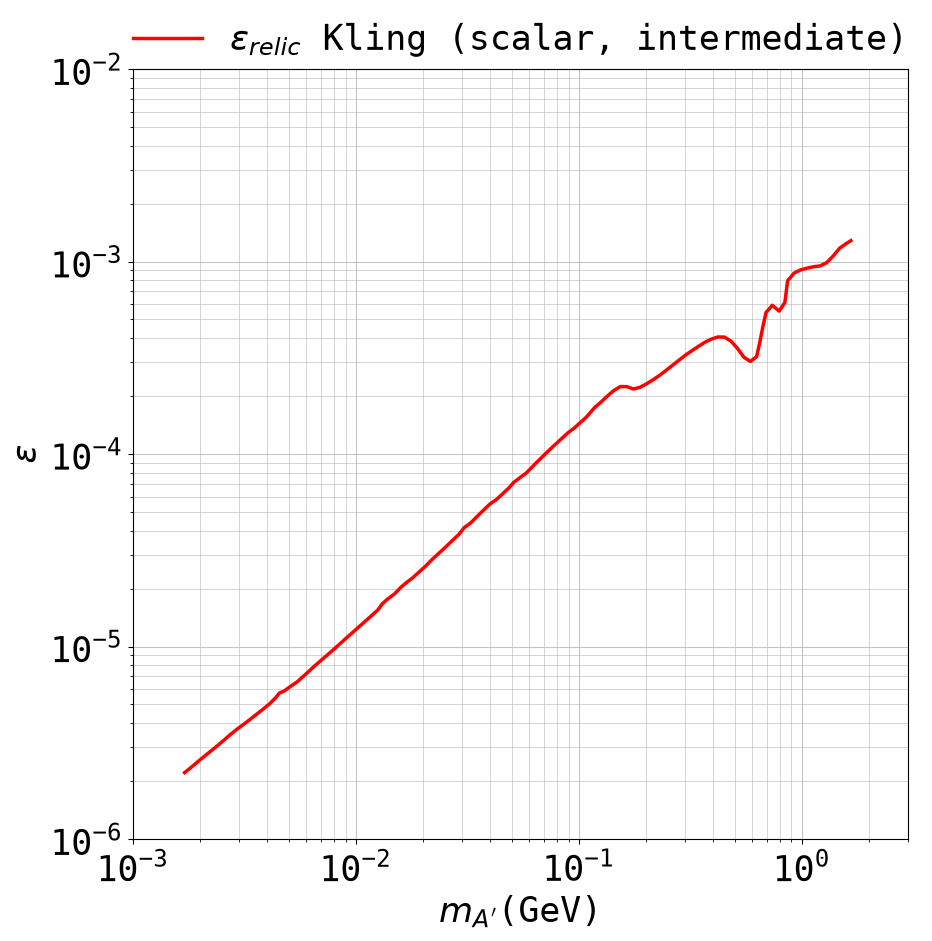

In [68]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"$\varepsilon_{relic}$ Kling (scalar, intermediate)")

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-3
x_max = 3

y_min = 1e-6
y_max = 1e-2

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
#plt.savefig("figures/relic_abundance_kling_0.pdf", bbox_inches='tight')
plt.show()

In [69]:
### Rough calculation for relic aboundance:

Mpl = 2.435323e18 # Reduced planck mass in GeV
mpl = 1.220890e19 # Planck mass in GeV

OmegaDM = 0.265 #Without reduced Hubble constant factor

# Epsilon for the relic line taking xf as a constant and as a function of
# the thermal production cross section

def eps_approx0(ma, alpha, alphaD, mchi):
    xf = 20
    return np.sqrt(6e-9/(sigmavrel(1, ma, alpha, alphaD, mchi, xf)))

def eps_approx1(ma, alpha, alphaD, mchi):
    xf = np.log(6e-9*mpl*mchi)
    return np.sqrt(6e-9/(sigmavrel(1, ma, alpha, alphaD, mchi, xf)))

In [70]:
# Some of the testing parameters:

alpha = 1/137
alphaD = 0.1

ma = np.logspace(-2, 2, 10000)  # Mass range from 0.1 GeV to 1000 GeV

mchi = 0.6*ma

eps_approx_0 = eps_approx0(ma, alpha, alphaD, mchi)

eps_approx_1 = eps_approx1(ma, alpha, alphaD, mchi)

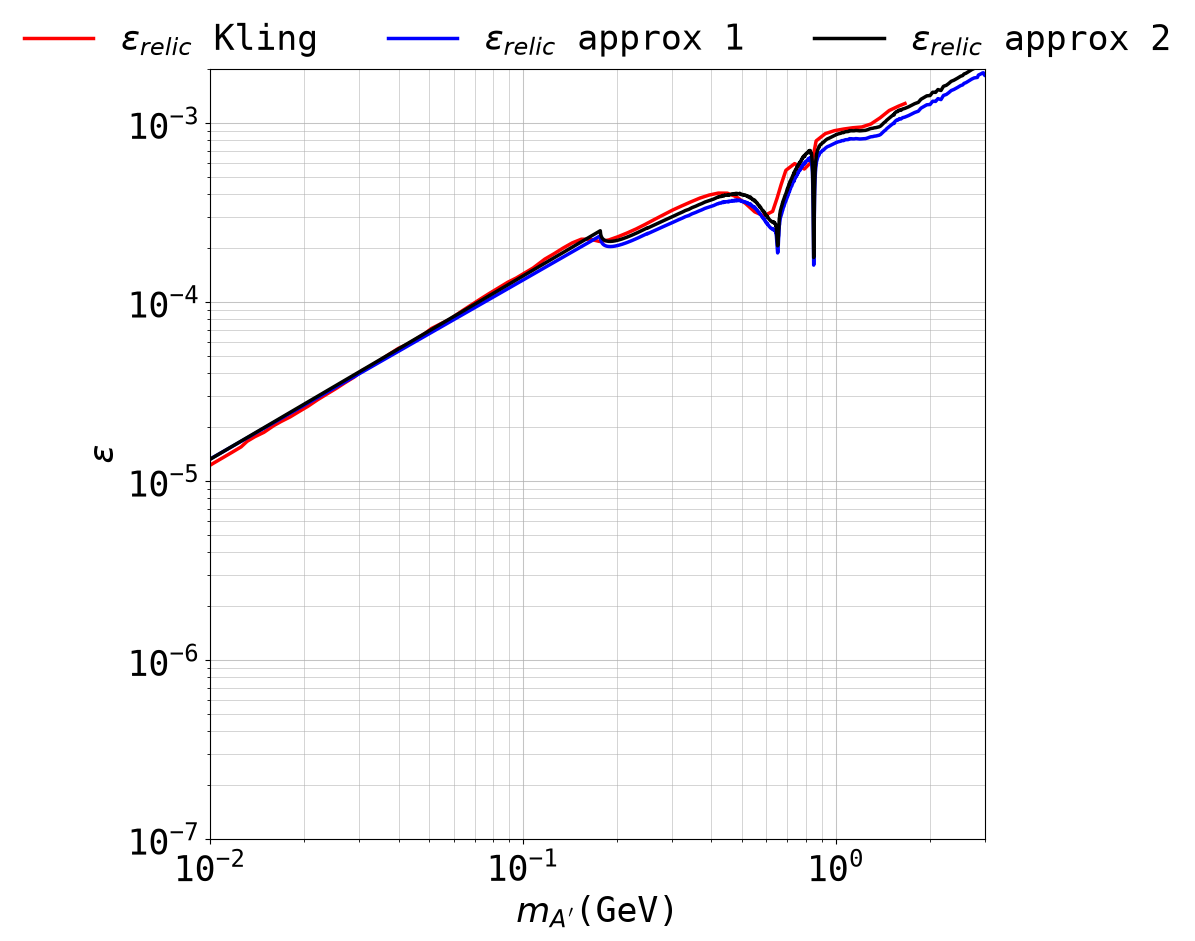

In [71]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Lock the square shape ax.set_aspect('equal', adjustable='datalim')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"$\epsilon_{relic}$ Kling")
plt.plot(ma, eps_approx_0, color = 'blue', linewidth = 2.5, label = r"$\epsilon_{relic}$ approx 1")
plt.plot(ma, eps_approx_1, color = 'black', linewidth = 2.5, label = r"$\epsilon_{relic}$ approx 2")

# Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1, 2]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
#plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

### Better approximations for $x_f$ and $\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{relic}}$

Using the freeze out condition $\Gamma(x_f) = H(x_f)$ it is possible to arrive at the following trascendental equation for $x_f$:

$$
e^{x_f} = \sqrt{\frac{90}{\pi^2}} g_\chi \frac{M_{\text{pl}}}{(2 \pi)^{3/2}} m_\chi \left\langle \sigma v \right\rangle_f x_f^{1/2} (g_*(m_\chi/x_f))^{-1/2}
$$

with

$$
\left\langle \sigma v \right\rangle_f = \frac{2 \pi}{9 \sqrt{10}} \frac{\sqrt{g_*(m_\chi/x_f)}}{g_{*s}(m_\chi/x_f)} g_{*s}(T_0) \frac{T_0^3}{H_0^2 M_{\text{pl}} \Omega_{\text{DM}}} x_f
$$

We can solve for $x_f$ numerically.

First, we need tabulated values for $g_*$ and $g_{*s}$:

In [72]:
### Effective dof from data/effective_dof.csv:

# The QCD transition temperature is not settled, so the table lists the
# 150-214 MeV window once per candidate, tagged in the last column by
# which choice(s) the row belongs to ('All' outside that window).
qcd_transition = "214"          # "214", "170" or "150" MeV

dof_table = np.genfromtxt("data/effective_dof.csv", delimiter=',', names=True,
                          dtype=None, encoding='utf-8')

keep_dof = np.array([m == "All" or qcd_transition in m
                     for m in dof_table["transition_temperature_model"]])

T_dof = dof_table["kBT_eV"][keep_dof]*1e-9        # eV -> GeV
gstar_e = dof_table["g_star_e"][keep_dof]
gstar_s = dof_table["g_star_s"][keep_dof]

# Sort on (T, g*_e), not T alone:
order = np.lexsort((gstar_e, T_dof))
T_dof, gstar_e, gstar_s = T_dof[order], gstar_e[order], gstar_s[order]

# Interpolate against log T:
logT_dof = np.log(T_dof)

# interp1d needs a strictly increasing x, so push each tie up by one float
# step.
for i in range(1, len(logT_dof)):
    if logT_dof[i] <= logT_dof[i-1]:
        logT_dof[i] = np.nextafter(logT_dof[i-1], np.inf)

gstar_e_interp = interpolate.interp1d(logT_dof, gstar_e, bounds_error=False,
                                      fill_value=(gstar_e[0], gstar_e[-1]))

gstar_s_interp = interpolate.interp1d(logT_dof, gstar_s, bounds_error=False,
                                      fill_value=(gstar_s[0], gstar_s[-1]))

def gstarfun(T):
    """g*_e at temperature T in GeV, interpolated from the tabulated values."""
    return gstar_e_interp(np.log(np.asarray(T, dtype=float)))

def gstarsfun(T):
    """g*_s at temperature T in GeV, interpolated from the tabulated values."""
    return gstar_s_interp(np.log(np.asarray(T, dtype=float)))

In [73]:
gchi = 2

H0 = 1.438e-42 # in GeV
T0 = 2.35e-13 # in GeV

gstarsT0 = gstarsfun(T0)

def sigmavrelic(xf, mchi):
    return 2*3.79*(1+1)*xf**2*2*np.pi**2*mchi*T0**3*gstarsT0/(gstarsfun(mchi/xf)/np.sqrt(gstarfun(mchi/xf))*mpl*mchi*45*3*H0**2*Mpl**2*OmegaDM)

def xfreeze(vare, ma, alpha, alphaD, mchi, xf=20.0):
    """Freeze out x, KT (5.48) with n = 1."""
    sigma0 = sigmavrel(vare, ma, alpha, alphaD, mchi, 1)
    A = np.log(1/2*(1+1)*0.038*gchi*mpl*mchi*sigma0/np.sqrt(gstarfun(mchi/xf)))
    return A - (1+1/2)*np.log(A)

def relic_line_point(ma, alpha, alphaD, mchi, x0=20.0, tol=1e-12, itmax=100):
    """The (eps, xf) pair on the relic line, solved together."""
    mchi = np.asarray(mchi, dtype=float)
    sigma0_unit = sigmavrel(1, ma, alpha, alphaD, mchi, 1)   # eps^2 divided out
    xf = x0*np.ones_like(mchi)
    eps = np.sqrt(sigmavrelic(xf, mchi)/sigma0_unit)

    for _ in range(itmax):
        xf = xfreeze(eps, ma, alpha, alphaD, mchi, xf)
        epsnew = np.sqrt(sigmavrelic(xf, mchi)/sigma0_unit)
        step = np.max(np.abs(np.log(epsnew/eps)))
        eps = epsnew
        if step < tol:
            break

    return eps, xf

def eps_approx2(ma, alpha, alphaD, mchi):
    """xf frozen at 20, so no iteration is needed."""
    xf = 20
    return np.sqrt(sigmavrelic(xf, mchi)/(sigmavrel(1, ma, alpha, alphaD, mchi, 1)))

def eps_approx3(ma, alpha, alphaD, mchi):
    """xf solved self consistently with eps."""
    return relic_line_point(ma, alpha, alphaD, mchi)[0]

### A third route to xf:

def sigmav_target(xf, mchi, n=1):
    """<sigma v> at freeze out that reproduces OmegaDM."""
    T = mchi/xf
    return (4*np.pi/(9*np.sqrt(10))*np.sqrt(gstarfun(T))/gstarsfun(T)
            *gstarsT0*T0**3/(H0**2*Mpl**3*OmegaDM)*xf)

def xfreeze_gamma(mchi, n=1, x0=20.0, tol=1e-12, itmax=200):
    """xf from Gamma(xf) = H(xf), i.e. n_eq <sigma v> = H:"""
    mchi = np.asarray(mchi, dtype=float)
    x = x0*np.ones_like(mchi)
    for _ in range(itmax):
        rhs = (np.sqrt(90/np.pi**2)*gchi*Mpl/(2*np.pi)**1.5*mchi
               *sigmav_target(x, mchi, n)/2*np.sqrt(x)/np.sqrt(gstarfun(mchi/x)))
        xnew = np.log(rhs)
        step = np.max(np.abs(xnew - x))
        x = xnew
        if step < tol:
            break
    return x

def eps_approx4(ma, alpha, alphaD, mchi, n=1):
    """eps from Gamma = H freeze out matched to the target cross section."""
    xf = xfreeze_gamma(mchi, n)
    return np.sqrt(sigmav_target(xf, mchi, n)
                   /sigmavrel(1, ma, alpha, alphaD, mchi, xf))

In [74]:
eps_approx_2 = eps_approx2(ma, alpha, alphaD, mchi)
eps_approx_3 = eps_approx3(ma, alpha, alphaD, mchi)
eps_approx_4 = eps_approx4(ma, alpha, alphaD, mchi)

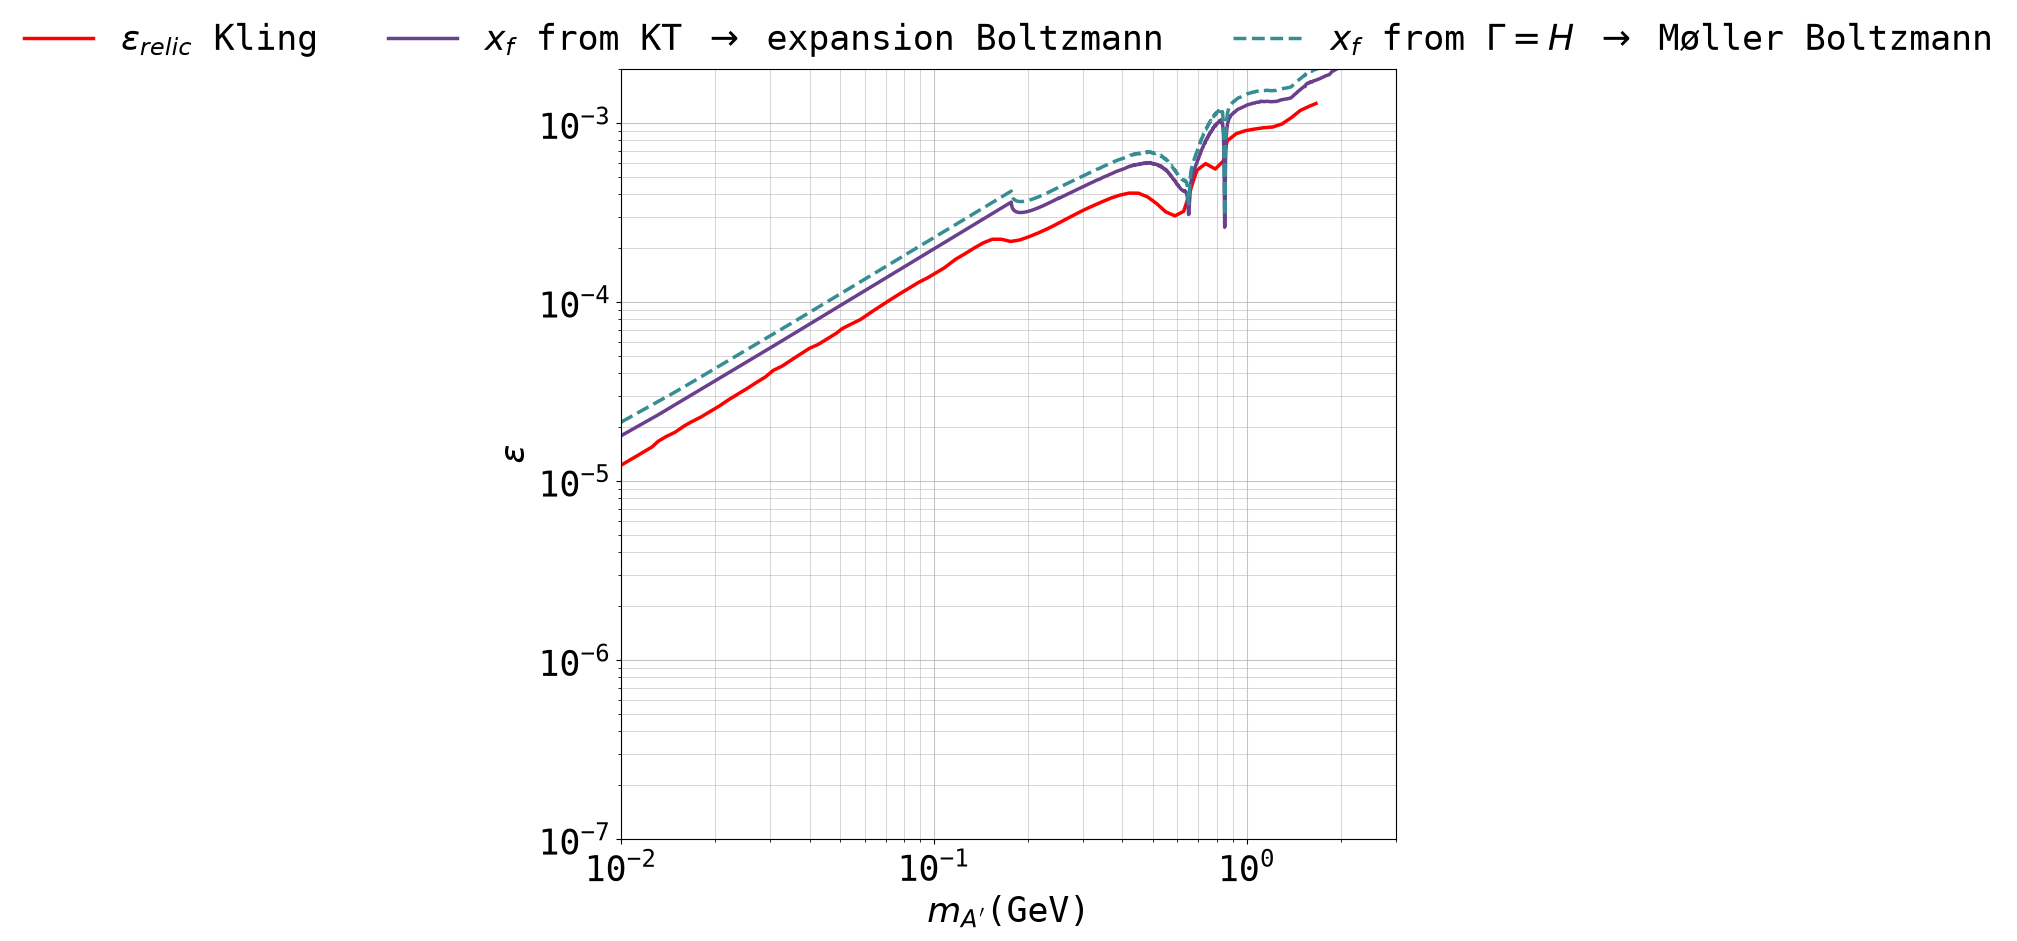

In [75]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Lock the square shape ax.set_aspect('equal', adjustable='datalim')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"$\epsilon_{relic}$ Kling")
# plt.plot(ma, eps_approx_0, color = 'blue', linewidth = 2.5, label =
# r"approx 1") plt.plot(ma, eps_approx_1, color = 'black', linewidth =
# 2.5, label = r"approx 2") plt.plot(ma, eps_approx_2, color = 'green',
# linewidth = 2.5, label = r"approx 3")
plt.plot(ma, eps_approx_3, color = '#6a408d', linewidth = 2.5,
         label = r"$x_f$ from KT $\rightarrow$ expansion Boltzmann")
plt.plot(ma, eps_approx_4, linestyle = '--', color = '#378d94', linewidth = 2.5,
         label = r"$x_f$ from $\Gamma = H$ $\rightarrow$ Møller Boltzmann")

# Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1, 2]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
#plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

### Using the Boltzmann equation:

The complete and more accurate way of solving for the relic abundance comes from solving the Boltzmann equation for out-of-equilibrium particle numbers. Through some standard procedures I will omit, the differential equation can be written in term of the adimensional variable $Y_\chi$, defined as (note some conventions differ on the normalization. We are taking Kolb and Turner's normalization):

$$
Y_{\chi} = \frac{n_\chi}{s},
$$

where $s$ is the entropy density, which can be written as a function of $x$ (or temperature):

$$
s = \frac{2 \pi^2}{45} g_{*s}\left( \frac{m_\chi}{x} \right) \left( \frac{m_\chi}{x} \right)^3,
$$

and $g_{*s}$ are the relativistic degrees of freedom in entropy. The intermediate behaviour of $g_{*s}$ is relatively complicated, and can change abruptly close to the QCD phase transition (confinement into hadrons). For that reason, we use tabulated values interpolated into a functional form.

The Boltmann equation in terms of $Y$ are known as the Riccati equations:

$$
\frac{dY}{dx} = \frac{1}{2} \frac{1}{3H(x)} \frac{ds}{dx} \left\langle \sigma v \right\rangle \left(  Y^2 - Y^2_{\text{eq}}\right)
$$

$$
\frac{ds}{dx} = - \frac{2 \pi^2}{45}  \frac{m_\chi^3}{x^4}  \left( 3 +  \frac{d \ln g_{*s}}{d \ln T}\left( \frac{m_\chi}{x} \right) \right)
$$
If we assume radiation domination at the relevant temperatures, then the Hubble parameter might be written as:
$$
H(T) = \sqrt{\frac{\pi^2}{90}g_{*}(T)}\frac{T^2}{M_{\text{Pl}}},
$$
where $g_*$ is now the relativistic degrees of freedom in the energy density.

We also have that $Y_{\text{eq}}$ can be written in the limit of $x \gg 3$ as:
$$
Y_{\text{eq}} = \frac{45}{2 \pi^2} \frac{g}{g_{*s}(m_\chi/x)} \left( \frac{x}{2 \pi} \right)^{3/2} e^{-x}.
$$

Using these approximations we can integrate the diferential equation to obtain the $Y_\infty$:


In [76]:
# Defining the Riccati equation

def H(T): # Assuming radiation domination
    return np.sqrt(np.pi**2/90 * gstarfun(T))*T**2/Mpl

def s(mchi, x):
    return 2*np.pi**2/45 * gstarsfun(mchi/x)*mchi**3/x**3

def Yeq(x, g, mchi):
    return 45/(2*np.pi**2)* g/gstarsfun(mchi/x) * (x/(2*np.pi))**(3/2) * np.exp(-x)

### The entropy release.

def dlogglogT(T, h=0.05):
    """d ln g*_s / d ln T, by central difference on the interpolated table."""
    T = np.asarray(T, dtype=float)
    lT = np.log(T)
    return (np.log(gstarsfun(np.exp(lT + h)))
            - np.log(gstarsfun(np.exp(lT - h))))/(2*h)

def dsdx(x, mchi):
    """ds/dx at T = mchi/x, with s = (2 pi^2/45) g*_s(T) T^3."""
    T = mchi/x
    return -(2*np.pi**2/45)*mchi**3/x**4*gstarsfun(T)*(3 + dlogglogT(T))

def dYdxcore(x, Y, g, mchi, sigmav):
    """Shared right hand side, Gelmini form:"""
    return dsdx(x, mchi)/(2*3*H(mchi/x))*sigmav*(Y**2 - Yeq(x, g, mchi)**2)

def dYdx(x, Y, g, vare, ma, alpha, alphaD, mchi):
    """Scalar DM, <sigma v> from the 6/x velocity expansion."""
    return dYdxcore(x, Y, g, mchi,
                    sigmavrel(vare, ma, alpha, alphaD, mchi, x))

xi = 10
xf = 1000

dYdxsolver = lambda x,Y: dYdx(x, Y, g = 2, vare = 1e-3, ma = 1e-1, alpha = 1/137, alphaD = 0.1, mchi = 0.6*1e-1)

xarr = np.logspace(np.log10(xi), np.log10(xf), 10000)
sol = solve_ivp(dYdxsolver, (xarr[0], xarr[-1]), [Yeq(xi,2, mchi=0.6*1e-1)],
                method="Radau", first_step=1e-10,
                t_eval=xarr, rtol=1e-8, atol=1e-12)

In [77]:
def omega(mchi, Yinf):
    return mchi*Yinf*(2*np.pi**2/45)*gstarsT0*T0**3/(3*Mpl**2*H0**2) 

Finally, to translate $Y_\infty$ into the observed relic abundance of dark matter today, we have that for isentropic expansion (constant entropy per comoving volume) the number density of the species is simply:
$$
n_{\chi,0} = s_0 Y_\infty.
$$
Multiplying by the mass and dividing by the critical density, we obtain that the relic abundance can be simply written as:
$$
\Omega_{\chi} = \frac{2 \pi^2}{45} \frac{m_\chi}{3 H_0^2 M_{\text{pl}}^2} T_0^2 g_{*s}(T_0) Y_\infty.
$$

To reproduce the correct relic abundance, we must scan over the different parameters available for the model $\alpha_D$, $m_\chi$, $m_{A'}$ and $\epsilon$, which are encoded inside the annihilation cross section.

In [78]:
### Scan over (ma, vare) for the epsilon that reproduces the observed Omega.

# The model parameters are alphaD, ma, mchi and vare.

def omega_of(ma, vare, alphaD, mchi_over_ma=0.6,
             xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega at one (ma, vare) point, by integrating the Boltzmann eq."""
    mchi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdx(x, Y, 2, vare, ma, alpha, alphaD, mchi)
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, 2, mchi)],
                    method="Radau", rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mchi, sol.y[0][-1])

def solve_window(omfun, ma, v_lo, v_hi, target, tol=0.01, itmax=30):
    """Find the crossing Omega(vare) = target inside [v_lo, v_hi]."""
    om_lo = omfun(ma, v_lo)
    if np.isfinite(om_lo) and om_lo < target:
        return np.nan, "below"       # needs a smaller vare than the window holds
    om_hi = omfun(ma, v_hi)
    if np.isfinite(om_hi) and om_hi > target:
        return np.nan, "above"       # needs a larger vare than the window holds
    if not (np.isfinite(om_lo) and np.isfinite(om_hi)):
        return np.nan, None

    lo, hi = np.log(v_lo), np.log(v_hi)
    f_lo, f_hi = np.log(om_lo/target), np.log(om_hi/target)   # f_lo > 0 > f_hi
    held = 0

    for _ in range(itmax):
        # Where the chord through (lo, f_lo) and (hi, f_hi) hits zero:
        probe = (lo*f_hi - hi*f_lo)/(f_hi - f_lo)
        om_p = omfun(ma, float(np.exp(probe)))
        if not np.isfinite(om_p) or om_p <= 0:
            return np.nan, None
        f_p = np.log(om_p/target)
        if abs(f_p) < tol:
            return float(np.exp(probe)), "inside"

        if f_p > 0:                  # still too much DM, so vare must rise
            # Illinois tweak:
            if held > 0:
                f_hi *= 0.5
            lo, f_lo, held = probe, f_p, 1
        else:
            if held < 0:
                f_lo *= 0.5
            hi, f_hi, held = probe, f_p, -1

    # Tolerance never met:
    return float(np.exp((lo*f_hi - hi*f_lo)/(f_hi - f_lo))), "inside"

# log Omega vs log vare is close to a straight line of slope -2, but not
# exactly, because the freeze-out x drifts with the coupling.
LOGSLOPE = -1.8

def predict_eps(i, ma_grid, eps_found):
    """Extrapolate eps for mass i from the last two solved masses."""
    solved = [(m, e) for m, e in zip(ma_grid[:i], eps_found[:i]) if np.isfinite(e)]
    if not solved:
        return None
    if len(solved) == 1:
        return solved[-1][1]
    (m1, e1), (m2, e2) = solved[-2], solved[-1]
    slope = np.log(e2/e1)/np.log(m2/m1)
    return float(e2*(ma_grid[i]/m2)**slope)

def refine_eps(omfun, ma, guess, v_lo, v_hi, target, tol=0.01, itmax=6):
    """Walk from a nearby guess to the crossing Omega = target."""
    le = np.log(guess)
    for _ in range(itmax):
        om = omfun(ma, float(np.exp(le)))
        if not np.isfinite(om) or om <= 0:
            return np.nan
        r = np.log(om/target)
        if abs(r) < tol:
            return float(np.exp(le))
        le += r/(-LOGSLOPE)
        if not (np.log(v_lo) <= le <= np.log(v_hi)):
            return np.nan
    return float(np.exp(le))

def scan_relic_line(ma_grid, vare_lo, vare_hi, alphaD, mchi_over_ma=0.6,
                    target=None, tol=0.01, solver=None, verbose = False,
                    omega_fun=None):
    """eps(ma) reproducing the relic abundance, at fixed alphaD and mass ratio."""
    if omega_fun is None:
        omega_fun = omega_of
    if target is None:
        target = OmegaDM
    ma_grid = np.asarray(ma_grid, dtype=float)
    stats = {"nsolve": 0}

    def omfun(ma, vare):
        stats["nsolve"] += 1
        return omega_fun(ma, vare, alphaD, mchi_over_ma, **(solver or {}))

    eps = np.full(ma_grid.shape, np.nan)
    stop_note = None
    i_stop = len(ma_grid)

    for i, ma_i in enumerate(ma_grid):
        guess = predict_eps(i, ma_grid, eps)

        found = np.nan
        if guess is not None and vare_lo <= guess <= vare_hi:
            found = refine_eps(omfun, ma_i, guess, vare_lo, vare_hi, target, tol)

        if not np.isfinite(found):
            found, side = solve_window(omfun, ma_i, vare_lo, vare_hi, target, tol)
            if side == "above":
                stop_note = (f"crossing lies above the window at ma = {ma_i:.4g} GeV"
                             + (f" (extrapolated eps = {guess:.3e} > {vare_hi:g})"
                                if guess is not None else ""))
                i_stop = i
                break
            # 'below' or None:

        eps[i] = found

    nfound = int(np.isfinite(eps).sum())
    info = {"nsolve": stats["nsolve"], "nfound": nfound,
            "stop_note": stop_note, "i_stop": i_stop,
            "alphaD": alphaD, "mchi_over_ma": mchi_over_ma, "target": target,
            "model": omega_fun.__name__}

    if verbose:
        print(f"alphaD = {alphaD:g}, mchi/ma = {mchi_over_ma:g},"
              f" Omega target = {target:g}")
        print(f"solved {nfound} of {len(ma_grid)} masses in {stats['nsolve']}"
              f" ODE integrations ({stats['nsolve']/max(nfound, 1):.1f} per solved mass)")
        if stop_note is not None:
            print(f"stopped early at index {i_stop}: {stop_note}")
            print(f"  {len(ma_grid) - i_stop} masses left unscanned"
                  f" (ma >= {ma_grid[i_stop]:.4g} GeV)")
        if nfound:
            got = ma_grid[np.isfinite(eps)]
            print(f"  solved range ma = {got[0]:.4g} to {got[-1]:.4g} GeV")
        else:
            print(f"no vare in [{vare_lo:g}, {vare_hi:g}] reaches {target};"
                  f" Omega(ma={ma_grid[0]:.3g}, vare={vare_lo:g})"
                  f" = {omfun(ma_grid[0], vare_lo):.3e}")
    return eps, info

In [79]:
### Running the scan:

ma_scan1 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo1, vare_hi1 = 1e-5, 2e-3

eps_relic1, scan_info1 = scan_relic_line(ma_scan1, vare_lo1, vare_hi1,
                                       alphaD=0.1, mchi_over_ma=0.6)

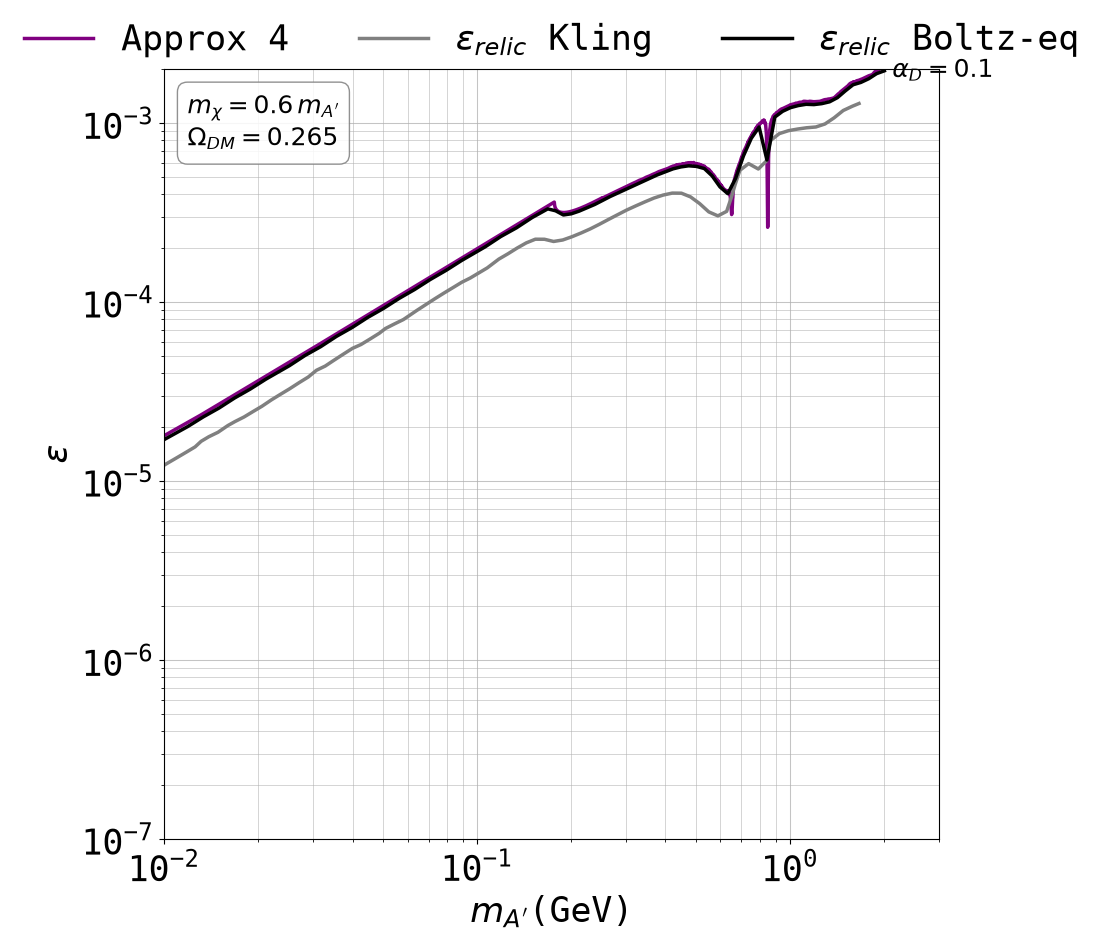

In [80]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

# plt.plot(ma, eps_approx_0, color = 'blue', linewidth = 2.5, label =
# r"$\varepsilon_{relic}$ Approx 1") plt.plot(ma, eps_approx_1, color =
# 'red', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Approx 2")
# plt.plot(ma, eps_approx_2, color = 'green', linewidth = 2.5, label =
# r"$\epsilon_{relic}$ Approx 3")
plt.plot(ma, eps_approx_3, color = 'purple', linewidth = 2.5, label = r"Approx 4")
plt.plot(ma_kling, eps_kling, color = 'grey', linewidth = 2.5,
         label = r"$\epsilon_{relic}$ Kling")

plt.plot(ma_scan1, eps_relic1, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

# The parameters that were held fixed rather than scanned over.

relic_curves = [(ma_scan1, eps_relic1, scan_info1)]

fixed_ratio = {info_i["mchi_over_ma"] for _, _, info_i in relic_curves}

ax.text(0.03, 0.97,
        "\n".join([r"$m_\chi = %g\, m_{A'}$" % scan_info1["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info1["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# alphaD differs between the Boltzmann curves here, so it is tagged on
# each one at its end rather than collected in the box, where it could not
# say which curve is which.
for ma_i, eps_i, info_i in relic_curves:
    ok_i = np.isfinite(eps_i)
    if ok_i.any():
        ax.text(ma_i[ok_i][-1]*1.06, eps_i[ok_i][-1],
                r"$\alpha_D = %g$" % info_i["alphaD"],
                va = 'center', ha = 'left', fontsize = 18)

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1, 2]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
#plt.savefig("figures/relic_abundance_scan_0.pdf", bbox_inches='tight')
plt.show()

### The better thermal averaging

Following Gelmini. The evolution of $Y$ as defined before comes as:

$$
\frac{dY}{dx} = \frac{1}{2} \frac{1}{3H(x)} \frac{ds}{dx} \left\langle \sigma v_{\text{Møller}} \right\rangle \left(  Y^2 - Y^2_{\text{eq}}\right)
$$

$$
\frac{ds}{dx} = - \frac{2 \pi^2}{45}  \frac{m_\chi^3}{x^4}  \left( 3 +  \frac{d \ln g_{*s}}{d \ln T}\left( \frac{m_\chi}{x} \right) \right)
$$

However, the thermal averaging must come as:

$$
\left\langle \sigma v_{\text{Møller}} \right\rangle = \frac{1}{8 m_\chi^4 (m_\chi/x) K_2^2(x)}  \int_{4 m_\chi^2}^\infty \sigma (s - 4m_\chi^2) \sqrt{s} K_1(\sqrt{s}x/m_\chi)ds
$$

Where $K_i$ are the modified Bessel functions of the second kind

$$
\sigma (s) = 2 \pi \epsilon^2 \alpha \alpha_D \frac{\left(s - 4 m_\chi^2 \right)^{1/2}}{s \left(s - m_{A'}^2 \right)^2} \left[ \sum_\ell \tilde{\sigma}_\ell(s) + R(\sqrt{s}) \tilde{\sigma}_\mu(s)  \right]
$$ 

where we defined the sigma tilde as:

$$
 \tilde{\sigma}_f (s) = Q_f^2 N_c^f \left(s - 4 m_f^2 \right)^{1/2} \left( s - \frac{1}{3} \left(s - 4 m_f^2 \right) \right) \Theta \left( \sqrt{s} - 2 m_f \right)
$$


In [81]:
### Gondolo-Gelmini thermal averaging.

from scipy.special import kve

def sigmatilde(s, mf, Q2Nc=1.0):
    """Q_f^2 N_c^f (s - 4mf^2)^{1/2} ( s - (s - 4mf^2)/3 ), zero below threshold."""
    s = np.asarray(s, dtype=float)
    opench = s > 4*mf**2
    beta2 = np.where(opench, s - 4*mf**2, 0.0)
    return Q2Nc*np.where(opench, np.sqrt(beta2)*(s - beta2/3), 0.0)

def sigma_ann(s, vare, ma, alpha, alphaD, mchi):
    """chi chi -> f fbar annihilation cross section at Mandelstam s."""
    s = np.asarray(s, dtype=float)
    opench = s > 4*mchi**2
    beta_chi = np.where(opench, np.sqrt(np.where(opench, s - 4*mchi**2, 0.0)), 0.0)

    lept = np.zeros_like(s)
    for ml in mleptons:
        lept = lept + sigmatilde(s, ml)
    hadr = R(np.sqrt(s))*sigmatilde(s, mleptons[1])

    return np.where(opench,
                    2*np.pi*vare**2*alpha*alphaD*beta_chi
                    / (s*(s - ma**2)**2)*(lept + hadr),
                    0.0)

# How far past threshold to integrate, in units of T, and how many nodes.
GG_UCUT = 60.0
GG_NODES = 4001

def sigmav_moller(x, vare, ma, alpha, alphaD, mchi,
                  ucut=GG_UCUT, nodes=GG_NODES):
    """<sigma v_Moller>(x), Gondolo-Gelmini."""
    x = float(x)
    T = mchi/x
    u = np.linspace(0.0, ucut, nodes)          # (sqrt(s) - 2 mchi)/T
    w = 2*mchi + u*T                           # sqrt(s)
    s = w*w

    sig = sigma_ann(s, vare, ma, alpha, alphaD, mchi)
    z = w*x/mchi                               # = 2x + u
    bessel = kve(1, z)/kve(2, x)**2*np.exp(-u)

    integrand = 2*sig*(s - 4*mchi**2)*w*w*bessel   # the 2w from ds = 2w dw
    return np.trapezoid(integrand, w)/(8*mchi**4*T)

def dYdxgg(x, Y, g, vare, ma, alpha, alphaD, mchi):
    """Scalar DM, <sigma v> from the full thermal average."""
    return dYdxcore(x, Y, g, mchi,
                    sigmav_moller(x, vare, ma, alpha, alphaD, mchi))

def Yeqgg(x, g, mchi):
    """Exact Bessel Y_eq, 45 g x^2 K2(x) / (4 pi^4 g*_s(T))."""
    x = np.asarray(x, dtype=float)
    return 45*g*x**2*kve(2, x)*np.exp(-x)/(4*np.pi**4*gstarsfun(mchi/x))

In [82]:
### Making the thermal average cheap enough to scan with.

from scipy.integrate import simpson

# sqrt(s) window over which R is resonance dominated and the grid has to
# stay fine.
GG_RES_LO, GG_RES_HI = 0.28, 1.15
GG_NODES_SMOOTH = 601      # no resonance in the window: the integrand is just u^(3/2) e^-u
GG_DW_RES = 5e-4           # target sqrt(s) spacing in GeV inside the window (phi is 4 MeV)
GG_NODES_MAX = 24001

def gg_grid(mchi, T, ucut=GG_UCUT):
    """Integration nodes in u = (sqrt(s) - 2 mchi)/T, uniform in sqrt(s)."""
    wlo, whi = 2*mchi, 2*mchi + ucut*T
    if whi < GG_RES_LO or wlo > GG_RES_HI:
        nodes = GG_NODES_SMOOTH
    else:
        nodes = int(np.clip((whi - wlo)/GG_DW_RES, GG_NODES_SMOOTH, GG_NODES_MAX))
    nodes += 1 - nodes % 2          # simpson wants an odd node count
    return np.linspace(0.0, ucut, nodes)

def sigmav_moller_unit(x, ma, mchi, ucut=GG_UCUT,
                       sigma_fun=sigma_ann, smooth=False):
    """<sigma v_Moller>(x) with eps^2 alpha alphaD divided out."""
    x = float(x)
    T = mchi/x
    # smooth=True skips the resonance refinement:
    u = (np.linspace(0.0, ucut, GG_NODES_SMOOTH) if smooth
         else gg_grid(mchi, T, ucut))
    w = 2*mchi + u*T
    s = w*w

    sig = sigma_fun(s, 1.0, ma, 1.0, 1.0, mchi)
    bessel = kve(1, 2*x + u)/kve(2, x)**2*np.exp(-u)
    return simpson(2*sig*(s - 4*mchi**2)*w*w*bessel, x=w)/(8*mchi**4*T)

# One interpolant per (ma, mchi).
GG_XLO, GG_XHI, GG_XPTS = 2.0, 3e3, 193
_gg_cache = {}

def sigmav_unit_table(ma, mchi, sigma_fun=sigma_ann, smooth=False):
    """log-log cubic interpolant of sigmav_moller_unit in x, memoised."""
    key = (float(ma), float(mchi), sigma_fun.__name__)
    tab = _gg_cache.get(key)
    if tab is None:
        xg = np.logspace(np.log10(GG_XLO), np.log10(GG_XHI), GG_XPTS)
        Fg = np.array([sigmav_moller_unit(_x, ma, mchi, sigma_fun=sigma_fun,
                                          smooth=smooth) for _x in xg])
        tab = interpolate.interp1d(np.log(xg), np.log(Fg), kind="cubic",
                                   bounds_error=False,
                                   fill_value=(np.log(Fg[0]), np.log(Fg[-1])))
        _gg_cache[key] = tab
    return tab

def sigmav_moller_fast(x, vare, ma, alpha, alphaD, mchi,
                       sigma_fun=sigma_ann, smooth=False):
    """Drop-in for sigmavrel, reading the memoised table."""
    return (vare**2*alpha*alphaD
            * np.exp(sigmav_unit_table(ma, mchi, sigma_fun, smooth)(np.log(x))))

def dYdxggf(x, Y, g, vare, ma, alpha, alphaD, mchi):
    """Same dYdxcore as dYdx, with the tabulated thermal average."""
    return dYdxcore(x, Y, g, mchi,
                    sigmav_moller_fast(x, vare, ma, alpha, alphaD, mchi))

def omega_of_gg(ma, vare, alphaD, mchi_over_ma=0.6,
                xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega with the full thermal average."""
    mchi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdxggf(x, Y, 2, vare, ma, alpha, alphaD, mchi)
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, 2, mchi)],
                    method="Radau", rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mchi, sol.y[0][-1])

def eps_approx5(ma, alpha, alphaD, mchi, n=1):
    """eps_approx4 made self consistent in <sigma v>."""
    xf = xfreeze_gamma(mchi, n)
    return np.sqrt(sigmav_target(xf, mchi, n)
                   /sigmav_moller_fast(xf, 1, ma, alpha, alphaD, mchi))

### Electron only annihilation, same thermal average.

def sigma_ann_e(s, vare, ma, alpha, alphaD, mchi):
    """chi chi -> e+ e- and nothing else."""
    s = np.asarray(s, dtype=float)
    opench = s > 4*mchi**2
    beta_chi = np.where(opench, np.sqrt(np.where(opench, s - 4*mchi**2, 0.0)), 0.0)
    return np.where(opench,
                    2*np.pi*vare**2*alpha*alphaD*beta_chi
                    /(s*(s - ma**2)**2)*sigmatilde(s, mleptons[0]),
                    0.0)

def omega_of_gg_e(ma, vare, alphaD, mchi_over_ma=0.6,
                  xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega with the full thermal average, electron channel only."""
    mchi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdxcore(x, Y, 2, mchi,
                                sigmav_moller_fast(x, vare, ma, alpha, alphaD, mchi,
                                                   sigma_fun=sigma_ann_e, smooth=True))
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, 2, mchi)], method="Radau",
                    rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mchi, sol.y[0][-1])

def sigma_ann_lep(s, vare, ma, alpha, alphaD, mchi):
    """chi chi -> l+ l- over all three charged leptons, no hadrons."""
    s = np.asarray(s, dtype=float)
    opench = s > 4*mchi**2
    beta_chi = np.where(opench, np.sqrt(np.where(opench, s - 4*mchi**2, 0.0)), 0.0)
    lept = np.zeros_like(s)
    for ml in mleptons:
        lept = lept + sigmatilde(s, ml)
    return np.where(opench,
                    2*np.pi*vare**2*alpha*alphaD*beta_chi
                    /(s*(s - ma**2)**2)*lept,
                    0.0)

def omega_of_gg_lep(ma, vare, alphaD, mchi_over_ma=0.6,
                    xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega with the full thermal average, all leptons, no hadrons."""
    mchi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdxcore(x, Y, 2, mchi,
                                sigmav_moller_fast(x, vare, ma, alpha, alphaD, mchi,
                                                   sigma_fun=sigma_ann_lep, smooth=True))
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, 2, mchi)], method="Radau",
                    rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mchi, sol.y[0][-1])

In [83]:
### Both treatments on one mass grid, against Kling.

ma_moller = np.unique(np.concatenate([
    np.logspace(np.log10(0.012), np.log10(0.40), 14),
    np.logspace(np.log10(0.40),  np.log10(1.20), 34),
    np.logspace(np.log10(1.20),  np.log10(1.62),  4)]))

eps_exp_m, info_exp_m = scan_relic_line(ma_moller, 1e-6, 5e-3, alphaD=0.1,
                                        mchi_over_ma=0.6, omega_fun=omega_of)
eps_gg, info_gg = scan_relic_line(ma_moller, 1e-6, 5e-3, alphaD=0.1,
                                  mchi_over_ma=0.6, omega_fun=omega_of_gg)

### Kling on the same masses, and the two ratios to it.

eps_kling_on_grid = np.exp(np.interp(np.log(ma_moller),
                                     np.log(ma_kling), np.log(eps_kling)))
inres = (ma_moller >= 0.50) & (ma_moller <= 0.92)

### The Gamma = H closed form with the model side taken from the same Moller
### integral, on the scan grid (one memoised table per mass).

eps_gg_cf = np.array([float(eps_approx5(np.array(_m), alpha, 0.1, np.array(0.6*_m)))
                      for _m in ma_moller])

### The same thermal average with only chi chi -> e+ e- open.

eps_gg_e, info_gg_e = scan_relic_line(ma_moller, 1e-6, 5e-2, alphaD=0.1,
                                      mchi_over_ma=0.6, omega_fun=omega_of_gg_e)

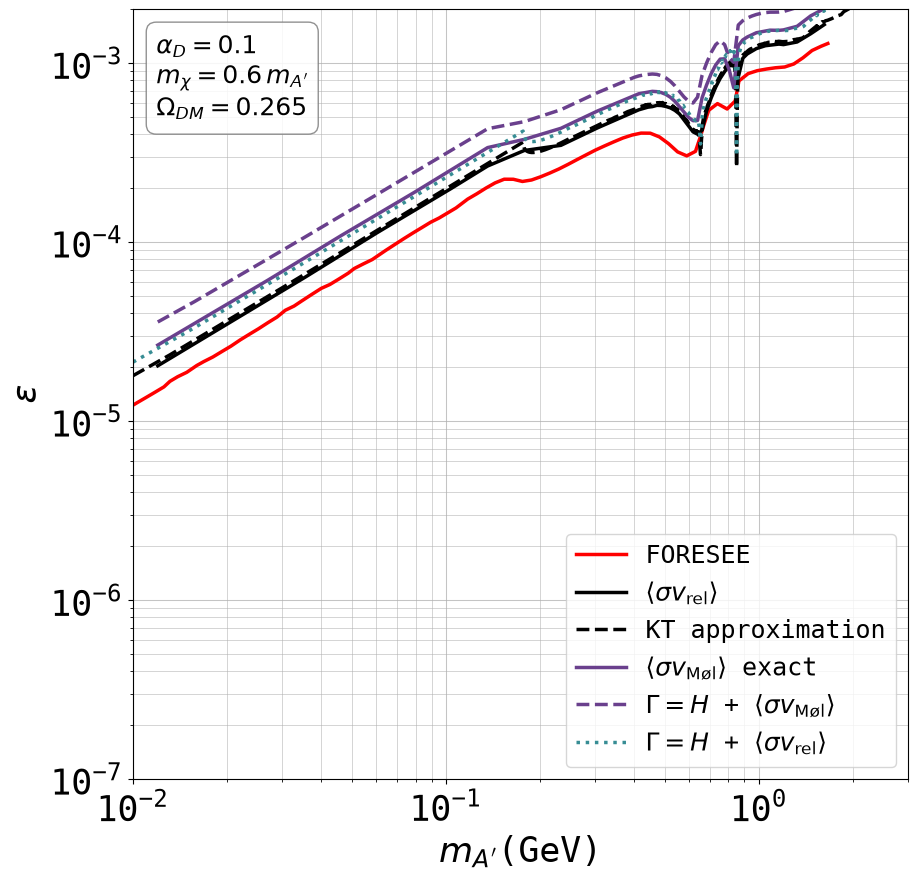

In [84]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

# Solid is Boltzmann, dashed is the closed form built from the SAME
# averaging, and colour says which averaging.

plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"FORESEE")
plt.plot(ma_moller, eps_exp_m, color = 'black', linewidth = 2.5,
         label = r"$\left\langle \sigma v_{\rm rel} \right\rangle$")
plt.plot(ma, eps_approx_3, linestyle = '--', color = 'black', linewidth = 2.5,
         label = r"KT approximation")
plt.plot(ma_moller, eps_gg, color = '#6a408d', linewidth = 2.5,
         label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact")
plt.plot(ma_moller, eps_gg_cf, linestyle = '--', color = '#6a408d', linewidth = 2.5,
         label = r"$\Gamma = H$ + $\left\langle \sigma v_{\rm M\o l} \right\rangle$")

# The mixed one:
plt.plot(ma, eps_approx_4, linestyle = ':', color = '#378d94', linewidth = 2.5,
         label = r"$\Gamma = H$ + $\left\langle \sigma v_{\rm rel} \right\rangle$")

# Shade where R is resonance dominated, i.e.
#ax.axvspan(0.50, 0.92, color = '#7e7e7e', alpha = 0.15, zorder = 0)

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % info_gg["alphaD"],
                   r"$m_\chi = %g\, m_{A'}$" % info_gg["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % info_gg["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # five entries no longer fit above the axes,
    ncol = 1,                      # and the lower right is empty anyway
    fontsize = 18,
    frameon = True                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_comparison_all.pdf", bbox_inches='tight')
plt.show()

### The same line from micrOMEGAs

The scan was run at the parameters used here, $\alpha_D = 0.1$ and $m_\chi = 0.6\, m_{A'}$. micrOMEGAs returns $\Omega h^2$ while this notebook works in $\Omega$, so the target it was given is $\Omega_{DM} h^2$ with $h$ read back from `H0`.

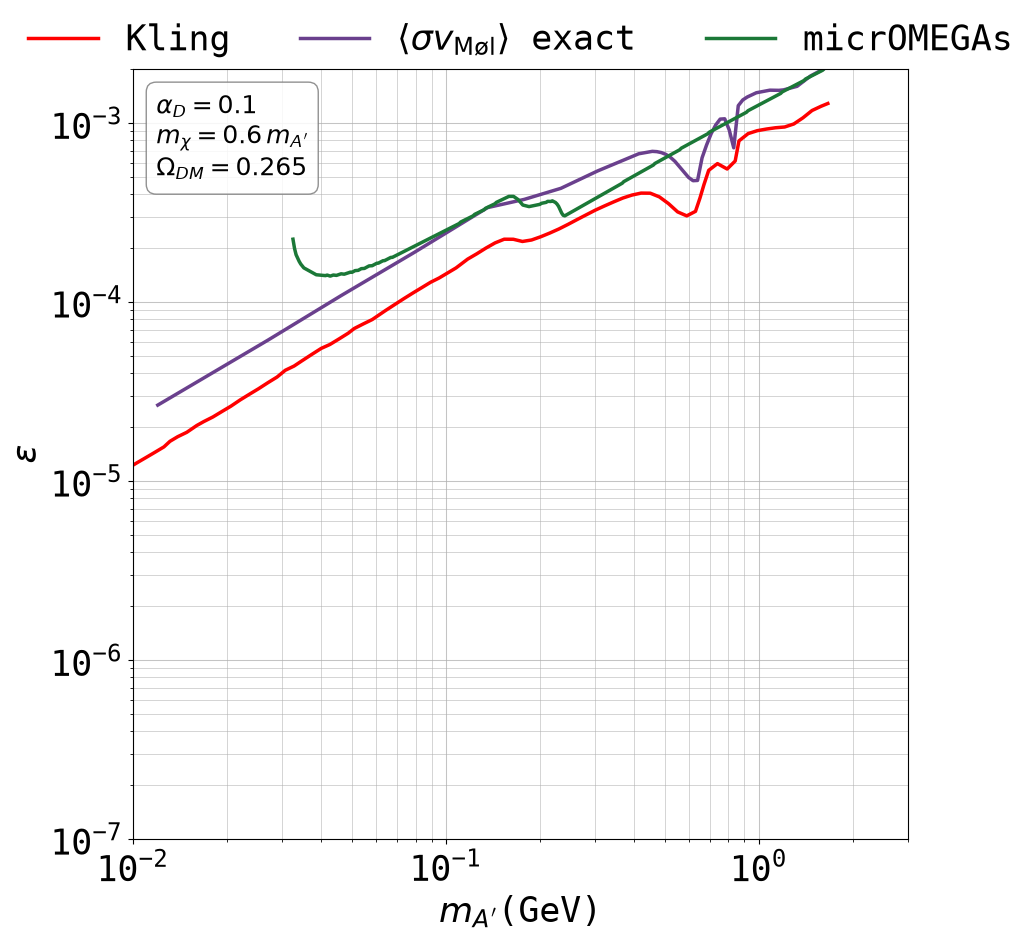

In [85]:
### Reading the micrOMEGAs scan.

micromegas = np.genfromtxt("data/micromegas_relic_line.csv",
                           delimiter = ",", names = True)

ma_micro  = micromegas["MAp"]
eps_micro = micromegas["eps"]
om_micro  = micromegas["omegah2"]
xf_micro  = micromegas["xf"]

### h from the H0 used above, which is what turns this notebook's Omega into
### the Omega h^2 micrOMEGAs solves for.

h_hubble = H0/2.1331969e-42          # 100 km/s/Mpc in GeV
omega_target_micro = OmegaDM*h_hubble**2

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"Kling")
plt.plot(ma_moller, eps_gg, color = '#6a408d', linewidth = 2.5,
         label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact")
plt.plot(ma_micro, eps_micro, color = '#1b7837', linewidth = 2.5,
         label = r"micrOMEGAs")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % 0.1,
                   r"$m_\chi = %g\, m_{A'}$" % scan_info1["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % OmegaDM]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3

y_min = 1e-7
y_max = 2e-3

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
#plt.savefig("figures/relic_abundance_micromegas.pdf", bbox_inches='tight')
plt.show()

Remove all couplings exect electrons in micromegas and the best approximation. Check for convergence.

### micrOMEGAs against the exact thermal average

The comparison worth making is against $\left\langle \sigma v_{\rm Mol} \right\rangle$ from the Gondolo-Gelmini integral rather than against the velocity expansion, since that is the treatment micrOMEGAs itself uses: both smear $R(\sqrt{s})$ over the thermal distribution of $s$ instead of reading it off at $\sqrt{s} = 2 m_\chi$. The expansion and Kling are kept on the plot as the reference points they were before.

The lower panel takes micrOMEGAs as the denominator, so a curve sitting at $1$ is one that agrees with it. The shaded band is where $R$ is resonance dominated, which is where the two averagings are expected to part company, and the dotted lines mark $\sqrt{s} \simeq 2 m_\chi$ at the muon and $2\pi$ thresholds -- the two places where the micrOMEGAs line visibly turns over.

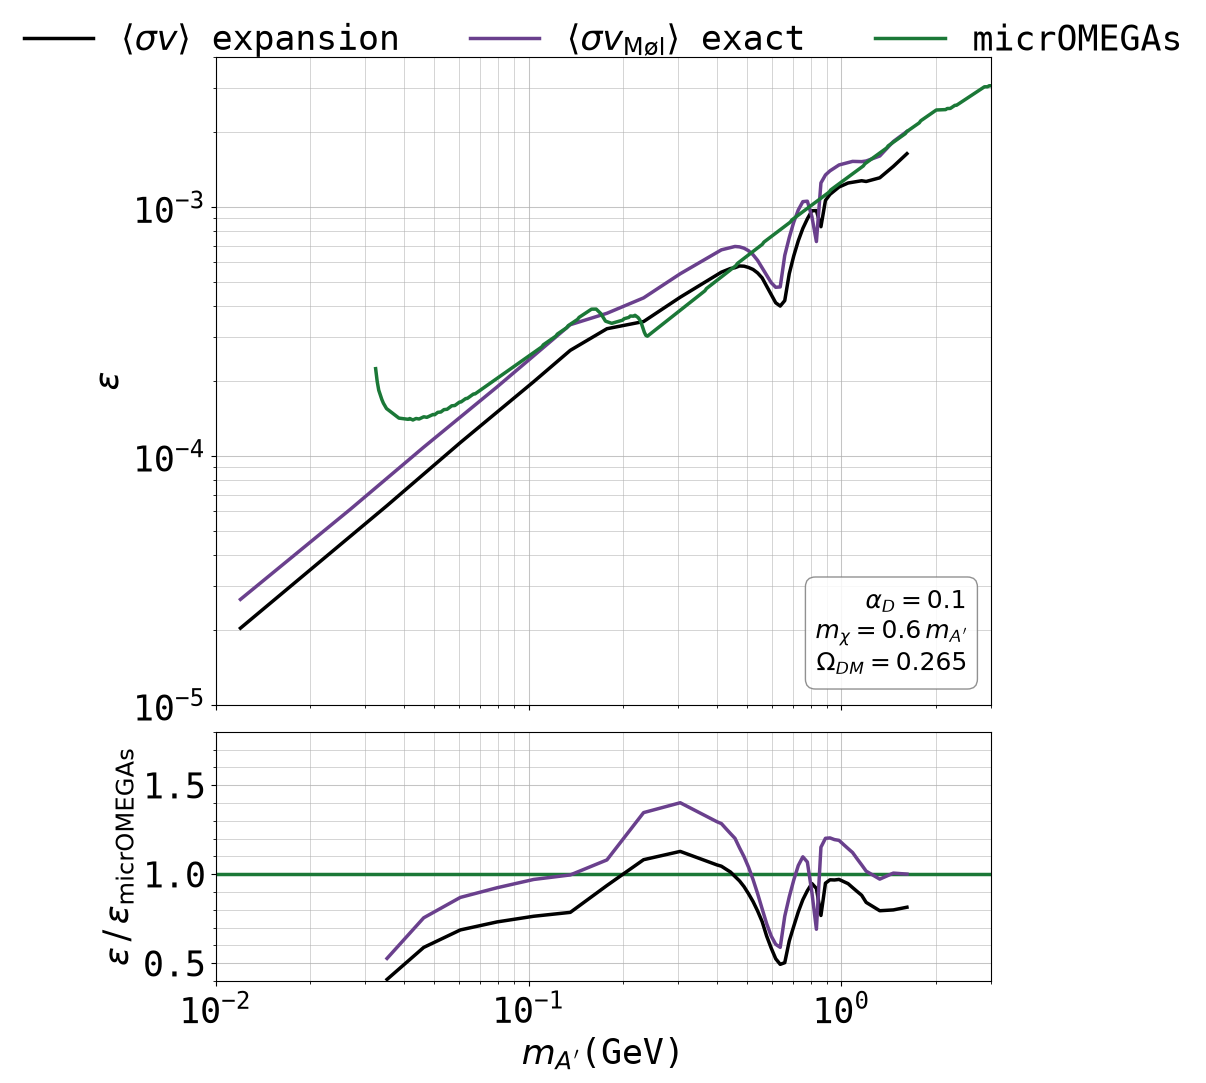

In [86]:
### micrOMEGAs against the exact (Moller) thermal averaging, on the grid the
### Moller scan used.

ok_micro = np.isfinite(eps_micro)
lo_micro, hi_micro = ma_micro[ok_micro].min(), ma_micro[ok_micro].max()

### Only where micrOMEGAs actually has a line.

overlap = (ma_moller >= lo_micro) & (ma_moller <= hi_micro)

eps_micro_on_grid = np.full(ma_moller.shape, np.nan)
eps_micro_on_grid[overlap] = np.exp(
    np.interp(np.log(ma_moller[overlap]),
              np.log(ma_micro[ok_micro]), np.log(eps_micro[ok_micro])))

### Ratios to micrOMEGAs, split at the resonance window as before.

inres_micro = (ma_moller >= 0.50) & (ma_moller <= 0.92)

for _i, _m in enumerate(ma_moller):
    if not overlap[_i]:
        continue

for _nm, _e in [("Moller   ", eps_gg), ("expansion", eps_exp_m)]:
    _r = _e/eps_micro_on_grid
    for _lab, _mask in [("smooth   ", overlap & ~inres_micro),
                        ("resonance", overlap & inres_micro)]:
        _rr = _r[_mask]
        _rr = _rr[np.isfinite(_rr)]
        if _rr.size == 0:
            continue

# Creating a plot:

fig, (ax, axr) = plt.subplots(2, 1, figsize=(10, 12), sharex=True,
                              gridspec_kw = dict(height_ratios = [2.6, 1],
                                                 hspace = 0.06))

axr.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")
axr.set_ylabel(r"$\varepsilon\,/\,\varepsilon_{\rm micrOMEGAs}$")

# Log Axis
for _a in (ax, axr):
    _a.set_xscale('log')
    # Major grid:
    _a.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)
    # Minor ticks and grid:
    _a.minorticks_on()
    _a.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)
    _a.set_axisbelow(True) # Ensure grid is below data
    # Shade where R is resonance dominated.
    #_a.axvspan(0.50, 0.92, color = '#7e7e7e', alpha = 0.15, zorder = 0)
    # sqrt(s) ~ 2 mchi at the muon and 2 pion thresholds, where the micrOMEGAs
    # line turns over.
    #for _thr in (2*0.1057/(2*0.6), 2*0.1396/(2*0.6)):
        #_a.axvline(_thr, color = '#7e7e7e', linestyle = ':', linewidth = 1.5,
                   #zorder = 0)

ax.set_yscale('log')

ax.plot(ma_moller, eps_exp_m, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v \right\rangle$ expansion")
ax.plot(ma_moller, eps_gg, color = '#6a408d', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact")
ax.plot(ma_micro, eps_micro, color = '#1b7837', linewidth = 2.5,
        label = r"micrOMEGAs")

# Bottom right:

ax.text(0.97, 0.04,
        "\n".join([r"$\alpha_D = %g$" % info_gg["alphaD"],
                   r"$m_\chi = %g\, m_{A'}$" % info_gg["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % OmegaDM]),
        transform = ax.transAxes, va = 'bottom', ha = 'right', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Ratio panel.

axr.axhline(1.0, color = '#1b7837', linewidth = 2.5)
axr.plot(ma_moller, eps_exp_m/eps_micro_on_grid, color = 'black', linewidth = 2.5)
axr.plot(ma_moller, eps_gg/eps_micro_on_grid, color = '#6a408d', linewidth = 2.5)

_kling_on_micro = np.exp(np.interp(np.log(ma_micro),
                                   np.log(ma_kling), np.log(eps_kling)))
#axr.plot(ma_micro, _kling_on_micro/eps_micro, color = 'red', linewidth = 2.5)

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 3,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3

# Tighter than the other relic plots on purpose:
y_min = 1e-5
y_max = 4e-3

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)
axr.set_xbound(x_min, x_max)
axr.set_ybound(0.4, 1.8)

# Save and show the figure:
plt.savefig("figures/relic_abundance_micromegas_moller.pdf", bbox_inches='tight')
plt.show()

### Micromegas without hadrons, for comparison

In [87]:
### Reading the micrOMEGAs scan run with only the electron coupling.

micromegas_e = np.genfromtxt("data/micromegas_relic_line_onlye.csv",
                             delimiter = ",", names = True)

ma_micro_e  = micromegas_e["MAp"]
eps_micro_e = micromegas_e["eps"]
om_micro_e  = micromegas_e["omegah2"]
xf_micro_e  = micromegas_e["xf"]

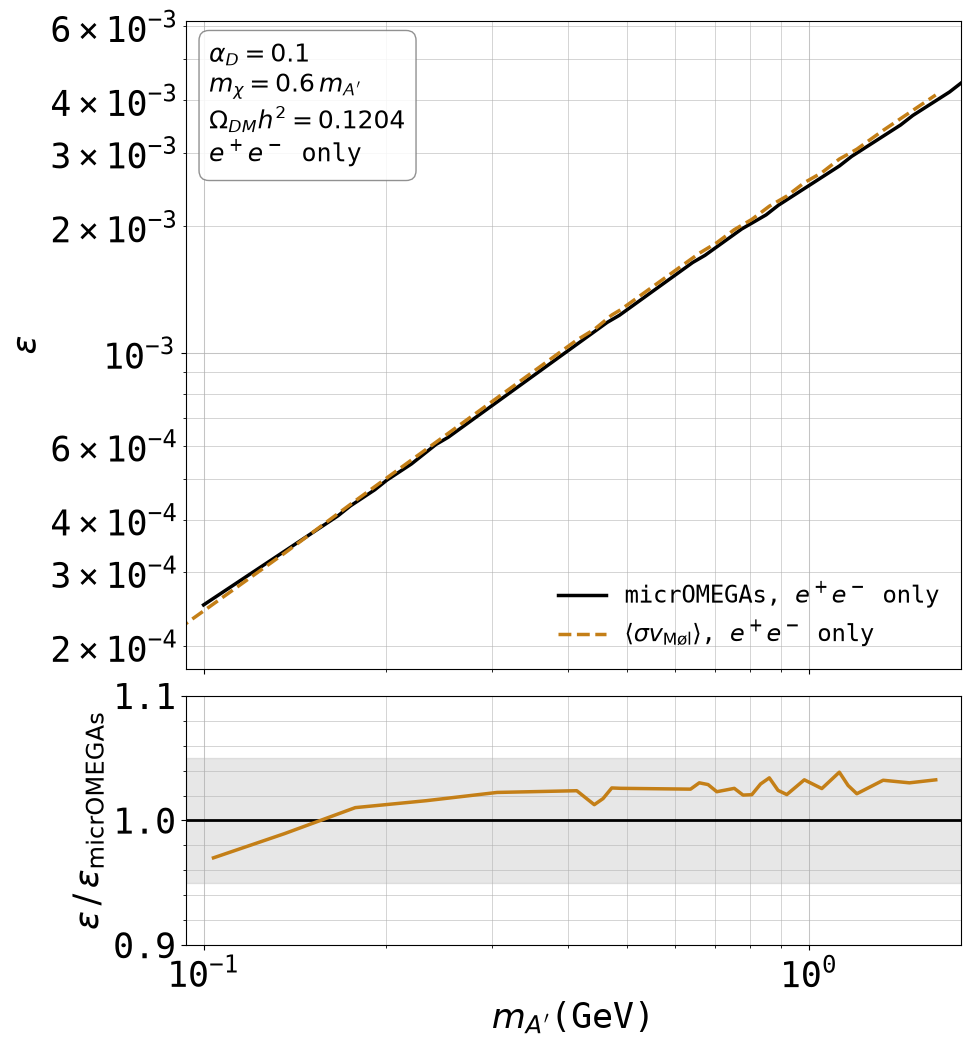

In [88]:
### The python Moller integral against micrOMEGAs, both with only the
### electron channel open.

mu_thr = 2*mleptons[1]/(2*0.6)

### Same alphaD, mass ratio, relic target and open channel, so the two
### lines are directly comparable.

ok_micro_e = np.isfinite(eps_micro_e)
lo_e, hi_e = ma_micro_e[ok_micro_e].min(), ma_micro_e[ok_micro_e].max()
overlap_e = (ma_moller >= lo_e) & (ma_moller <= hi_e)

eps_micro_e_grid = np.full(ma_moller.shape, np.nan)
eps_micro_e_grid[overlap_e] = np.exp(
    np.interp(np.log(ma_moller[overlap_e]),
              np.log(ma_micro_e[ok_micro_e]), np.log(eps_micro_e[ok_micro_e])))

ratio_e = eps_gg_e/eps_micro_e_grid

# Creating a plot:

fig, (ax, axr) = plt.subplots(2, 1, figsize=(10, 12), sharex=True,
                              gridspec_kw = dict(height_ratios = [2.6, 1],
                                                 hspace = 0.06))

axr.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")
axr.set_ylabel(r"$\varepsilon\,/\,\varepsilon_{\rm micrOMEGAs}$")

for _a in (ax, axr):
    _a.set_xscale('log')
    _a.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)
    _a.minorticks_on()
    _a.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)
    _a.set_axisbelow(True)
    #_a.axvline(mu_thr, color = '#7e7e7e', linestyle = ':', linewidth = 1.5, zorder = 0)

ax.set_yscale('log')

ax.plot(ma_micro_e, eps_micro_e, color = 'black', linewidth = 2.5,
        label = r"micrOMEGAs, $e^+e^-$ only")
ax.plot(ma_moller, eps_gg_e, linestyle = '--', color = '#c47f17', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$, $e^+e^-$ only")

axr.axhline(1.0, color = 'black', linewidth = 2.0)
axr.axhspan(0.95, 1.05, color = '#7e7e7e', alpha = 0.18, zorder = 0)
axr.plot(ma_moller, ratio_e, color = '#c47f17', linewidth = 2.5)

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % info_gg_e["alphaD"],
                   r"$m_\chi = %g\, m_{A'}$" % info_gg_e["mchi_over_ma"],
                   r"$\Omega_{DM} h^2 = %.4g$" % omega_target_micro,
                   r"$e^+e^-$ only"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

ax.legend(loc = 'lower right', fontsize = 17, frameon = False)

# Ranges set to the overlap:
_lo, _hi = ma_moller[overlap_e].min(), ma_moller[overlap_e].max()
_e = np.concatenate([eps_gg_e[overlap_e], eps_micro_e_grid[overlap_e]])
ax.set_xbound(0.9*_lo, 1.1*_hi)
ax.set_ybound(0.7*np.nanmin(_e), 1.5*np.nanmax(_e))
axr.set_ybound(0.9, 1.1)

plt.savefig("figures/micromegas_electrons.pdf", bbox_inches='tight')
plt.show()

### The same thing with every lepton but no hadrons

The step between the two sections above is large: `sigma_ann_e` drops the muon, the tau *and* the whole hadronic $R$ term at once, so a disagreement anywhere above $2 m_\mu$ has three possible causes. `sigma_ann_lep` splits that step, keeping the full lepton sum and dropping only $R(\sqrt{s})$.

Over the range scanned here that means $e$ and $\mu$, since the tau needs $m_\chi > 1.777$ GeV, i.e. $m_{A'} > 2.96$ GeV. The matching micrOMEGAs scan is `micromegas_relic_line_onlyl.csv`, run under the same conditions.

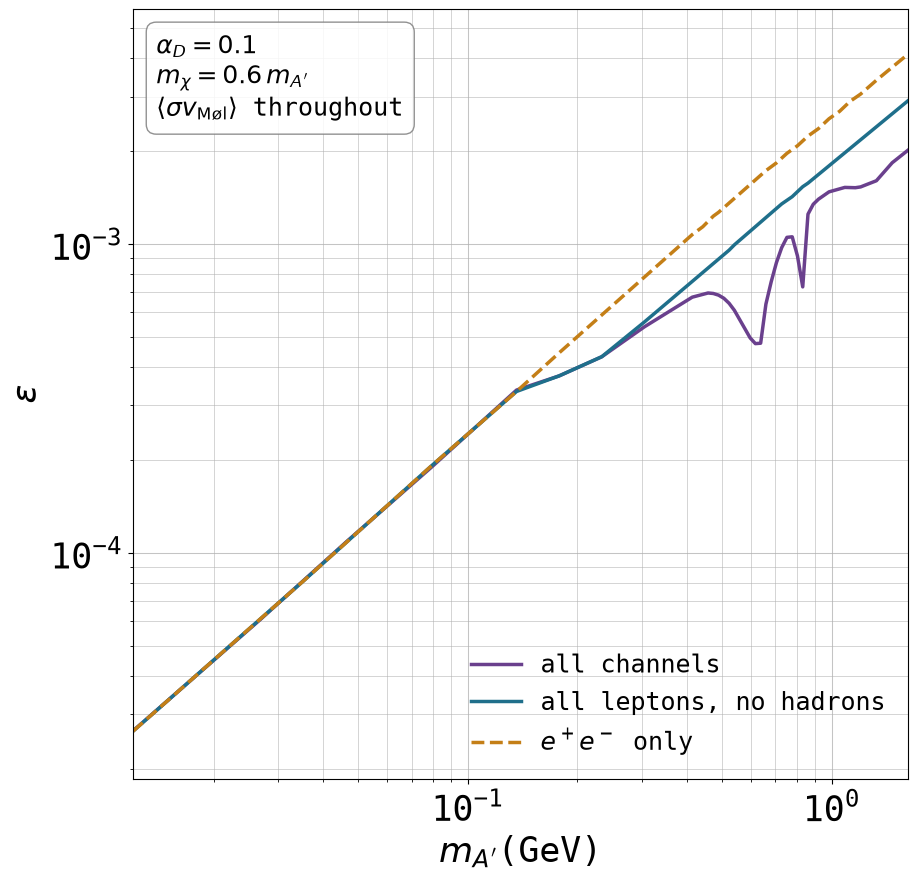

In [89]:
### All leptons, no hadrons.

eps_gg_lep, info_gg_lep = scan_relic_line(ma_moller, 1e-6, 5e-2, alphaD=0.1,
                                          mchi_over_ma=0.6,
                                          omega_fun=omega_of_gg_lep)

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)
ax.set_axisbelow(True)

# Shade where R is resonance dominated:
#ax.axvspan(0.50, 0.92, color = '#7e7e7e', alpha = 0.15, zorder = 0)
#for _thr in (2*mleptons[1]/(2*0.6), 2*0.1396/(2*0.6)):
    #ax.axvline(_thr, color = '#7e7e7e', linestyle = ':', linewidth = 1.5, zorder = 0)

ax.plot(ma_moller, eps_gg, color = '#6a408d', linewidth = 2.5,
        label = r"all channels")
ax.plot(ma_moller, eps_gg_lep, color = '#1f6f8b', linewidth = 2.5,
        label = r"all leptons, no hadrons")
ax.plot(ma_moller, eps_gg_e, linestyle = '--', color = '#c47f17', linewidth = 2.5,
        label = r"$e^+e^-$ only")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % info_gg_lep["alphaD"],
                   r"$m_\chi = %g\, m_{A'}$" % info_gg_lep["mchi_over_ma"],
                   r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ throughout"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

ax.legend(loc = 'lower right', fontsize = 18, frameon = False)

_all = np.concatenate([eps_gg, eps_gg_lep, eps_gg_e])
ax.set_xbound(ma_moller.min(), ma_moller.max())
ax.set_ybound(0.7*np.nanmin(_all), 1.4*np.nanmax(_all))

plt.savefig("figures/moller_channels.pdf", bbox_inches='tight')
plt.show()

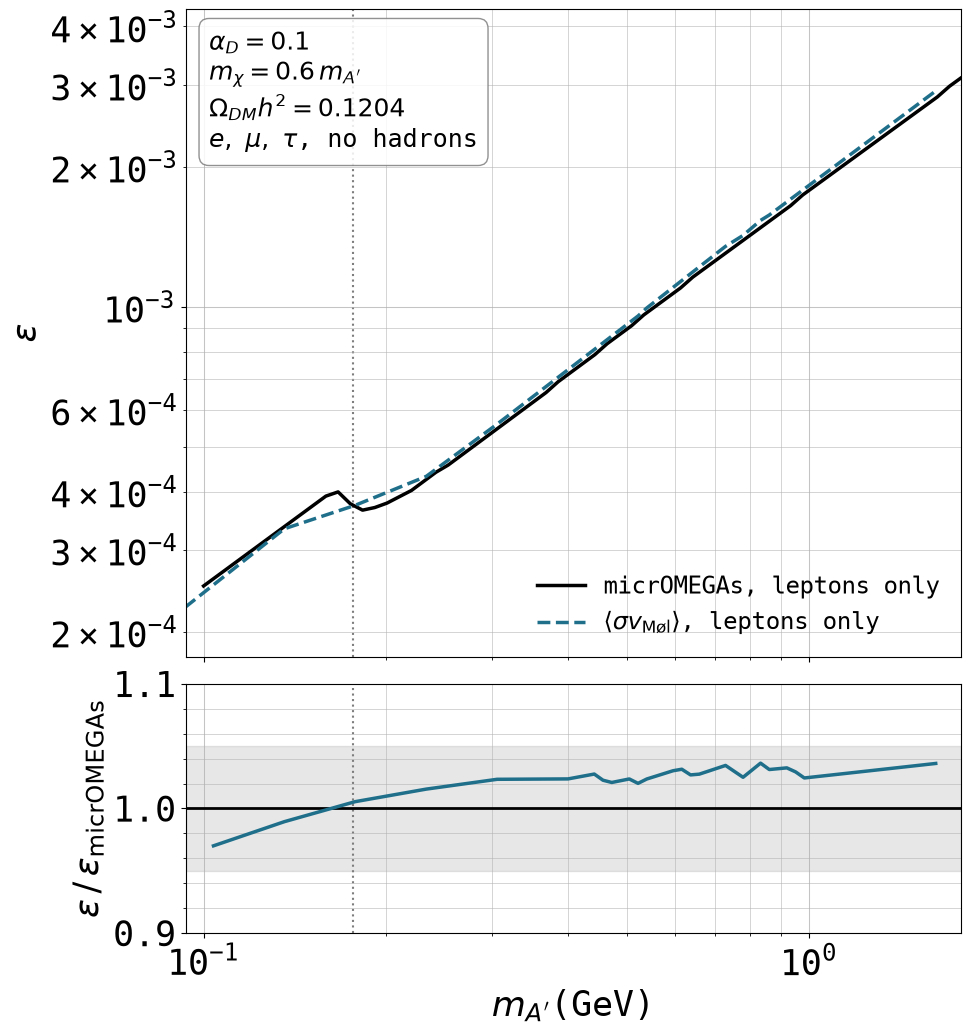

In [90]:
### The python Moller integral against micrOMEGAs, all leptons, no hadrons.

micromegas_l = np.genfromtxt("data/micromegas_relic_line_onlyl.csv",
                             delimiter = ",", names = True)
ma_micro_l, eps_micro_l = micromegas_l["MAp"], micromegas_l["eps"]

### The two standing consistency checks on the micrOMEGAs files themselves.

### Now the comparison.

ok_l = np.isfinite(eps_micro_l)
lo_l, hi_l = ma_micro_l[ok_l].min(), ma_micro_l[ok_l].max()
overlap_l = (ma_moller >= lo_l) & (ma_moller <= hi_l)

eps_micro_l_grid = np.full(ma_moller.shape, np.nan)
eps_micro_l_grid[overlap_l] = np.exp(
    np.interp(np.log(ma_moller[overlap_l]),
              np.log(ma_micro_l[ok_l]), np.log(eps_micro_l[ok_l])))

ratio_l = eps_gg_lep/eps_micro_l_grid

# Creating a plot:

fig, (ax, axr) = plt.subplots(2, 1, figsize=(10, 12), sharex=True,
                              gridspec_kw = dict(height_ratios = [2.6, 1],
                                                 hspace = 0.06))

axr.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")
axr.set_ylabel(r"$\varepsilon\,/\,\varepsilon_{\rm micrOMEGAs}$")

for _a in (ax, axr):
    _a.set_xscale('log')
    _a.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)
    _a.minorticks_on()
    _a.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)
    _a.set_axisbelow(True)
    _a.axvline(mu_thr, color = '#7e7e7e', linestyle = ':', linewidth = 1.5, zorder = 0)

ax.set_yscale('log')

ax.plot(ma_micro_l, eps_micro_l, color = 'black', linewidth = 2.5,
        label = r"micrOMEGAs, leptons only")
ax.plot(ma_moller, eps_gg_lep, linestyle = '--', color = '#1f6f8b', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$, leptons only")

axr.axhline(1.0, color = 'black', linewidth = 2.0)
axr.axhspan(0.95, 1.05, color = '#7e7e7e', alpha = 0.18, zorder = 0)
axr.plot(ma_moller, ratio_l, color = '#1f6f8b', linewidth = 2.5)

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % info_gg_lep["alphaD"],
                   r"$m_\chi = %g\, m_{A'}$" % info_gg_lep["mchi_over_ma"],
                   r"$\Omega_{DM} h^2 = %.4g$" % omega_target_micro,
                   r"$e,\ \mu,\ \tau$, no hadrons"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

ax.legend(loc = 'lower right', fontsize = 17, frameon = False)

_lo, _hi = ma_moller[overlap_l].min(), ma_moller[overlap_l].max()
_e = np.concatenate([eps_gg_lep[overlap_l], eps_micro_l_grid[overlap_l]])
ax.set_xbound(0.9*_lo, 1.1*_hi)
ax.set_ybound(0.7*np.nanmin(_e), 1.5*np.nanmax(_e))
axr.set_ybound(0.9, 1.1)

plt.savefig("figures/micromegas_leptons.pdf", bbox_inches='tight')
plt.show()

### Boltzmann equation scans for multiple parameters

We can run multiple scans for different $\alpha_D$ and $m_\chi/m_{A'}$:

In [91]:
### The alphaD = 0.1 baseline again, with the exact thermal average, so all
### three curves below share one treatment.

eps_relic1m, scan_info1m = scan_relic_line(ma_scan1, 1e-7, 2e-2,
                                           alphaD=0.1, mchi_over_ma=0.6,
                                           omega_fun=omega_of_gg)

In [92]:
ma_scan2 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo2, vare_hi2 = 1e-7, 2e-2

eps_relic2, scan_info2 = scan_relic_line(ma_scan2, vare_lo2, vare_hi2,
                                         alphaD=0.95, mchi_over_ma=0.6,
                                         omega_fun=omega_of_gg)

In [93]:
ma_scan3 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo3, vare_hi3 = 1e-7, 2e-2

eps_relic3, scan_info3 = scan_relic_line(ma_scan3, vare_lo3, vare_hi3,
                                         alphaD=0.03, mchi_over_ma=0.6,
                                         omega_fun=omega_of_gg)

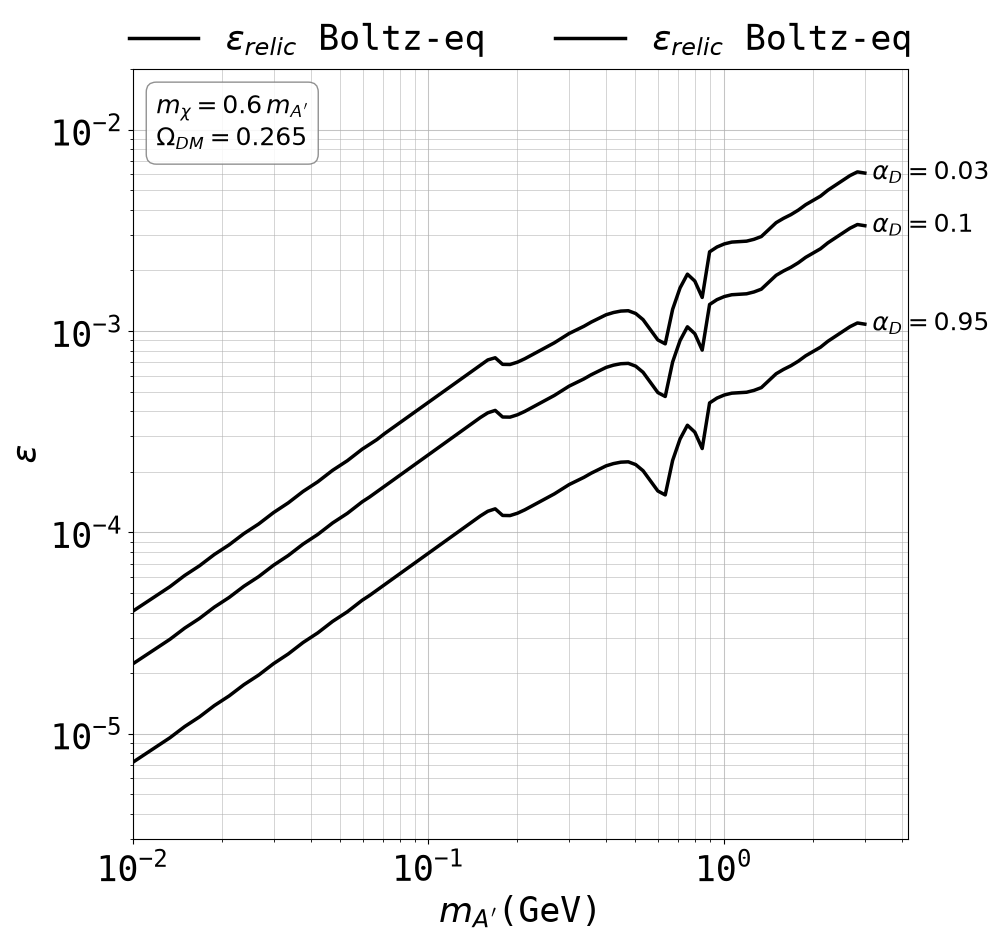

In [94]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_scan1, eps_relic1m, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

plt.plot(ma_scan2, eps_relic2, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

plt.plot(ma_scan3, eps_relic3, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

# The parameters that were held fixed rather than scanned over.

relic_curves = [(ma_scan1, eps_relic1m, scan_info1m),
                (ma_scan2, eps_relic2, scan_info2),
                (ma_scan3, eps_relic3, scan_info3)]

fixed_ratio = {info_i["mchi_over_ma"] for _, _, info_i in relic_curves}

ax.text(0.03, 0.97,
        "\n".join([r"$m_\chi = %g\, m_{A'}$" % scan_info1m["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info1m["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# alphaD differs between the Boltzmann curves here, so it is tagged on
# each one at its end rather than collected in the box, where it could not
# say which curve is which.
for ma_i, eps_i, info_i in relic_curves:
    ok_i = np.isfinite(eps_i)
    if ok_i.any():
        ax.text(ma_i[ok_i][-1]*1.06, eps_i[ok_i][-1],
                r"$\alpha_D = %g$" % info_i["alphaD"],
                va = 'center', ha = 'left', fontsize = 18)

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 4.2
x_range = x_max - x_min

y_min = 3e-6
y_max = 2e-2
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_scan_1.pdf", bbox_inches='tight')
plt.show()

We can also scan over mass ratios, remembering $0.5 m_{A'} \leq m_\chi \leq m_{A'}$ 

In [95]:
ma_scan4 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo4, vare_hi4 = 1e-7, 2e-2

eps_relic4, scan_info4 = scan_relic_line(ma_scan4, vare_lo4, vare_hi4,
                                         alphaD=0.1, mchi_over_ma=0.7,
                                         omega_fun=omega_of_gg)

In [96]:
ma_scan5 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo5, vare_hi5 = 1e-7, 2e-2

eps_relic5, scan_info5 = scan_relic_line(ma_scan5, vare_lo5, vare_hi5,
                                         alphaD=0.1, mchi_over_ma=0.8,
                                         omega_fun=omega_of_gg)

In [97]:
ma_scan6 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo6, vare_hi6 = 1e-7, 2e-2

eps_relic6, scan_info6 = scan_relic_line(ma_scan6, vare_lo6, vare_hi6,
                                         alphaD=0.1, mchi_over_ma=0.9,
                                         omega_fun=omega_of_gg)

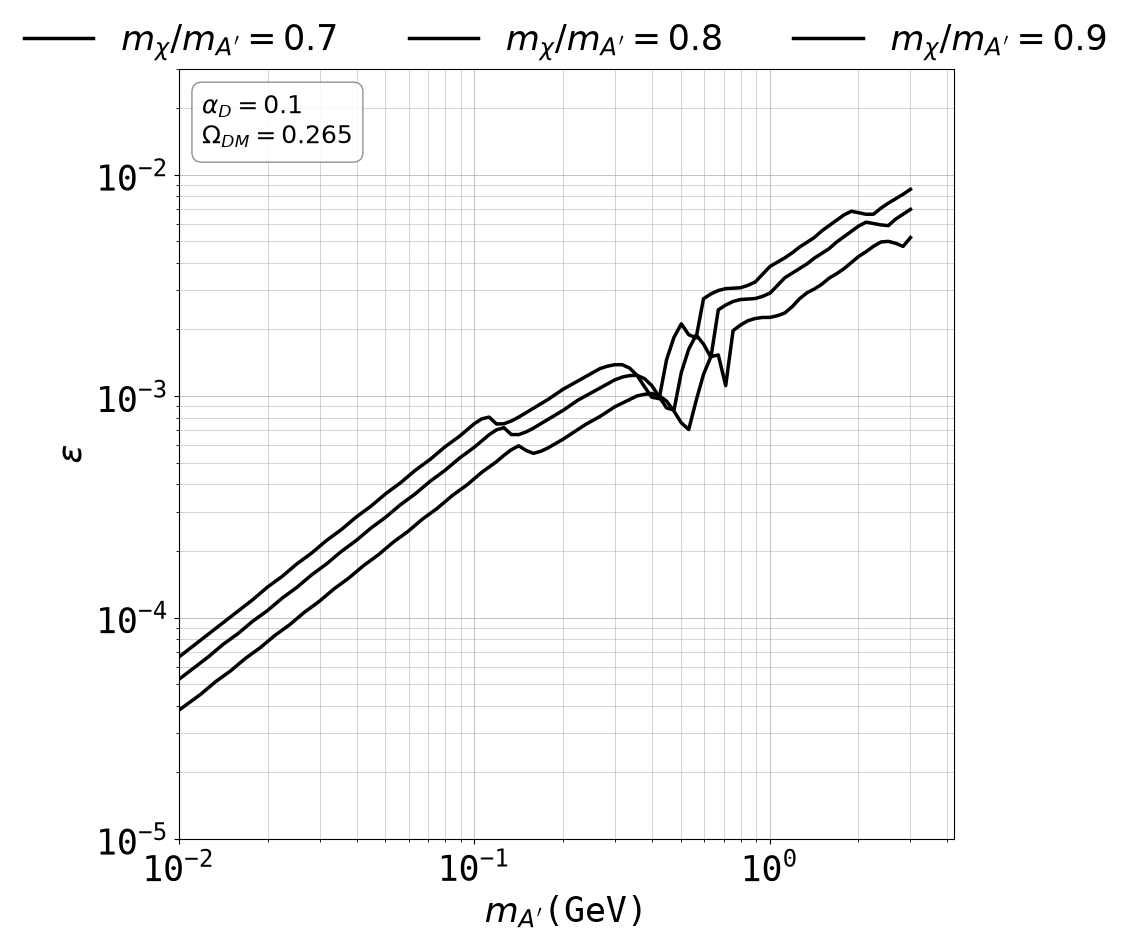

In [98]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

# On this figure mchi/ma is what varies between the curves, so alphaD is
# the one that goes in the fixed-parameter box.
relic_curves = [(ma_scan4, eps_relic4, scan_info4),
                (ma_scan5, eps_relic5, scan_info5),
                (ma_scan6, eps_relic6, scan_info6)]

for ma_i, eps_i, info_i in relic_curves:
    plt.plot(ma_i, eps_i, color = 'black', linewidth = 2.5,
             label = r"$m_\chi/m_{A'} = %g$" % info_i["mchi_over_ma"])

# The parameters that were held fixed rather than scanned over, read back
# out of the scan info dicts so the annotation cannot drift away from what
# was actually run.

fixed_alphaD = {info_i["alphaD"] for _, _, info_i in relic_curves}

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % relic_curves[0][2]["alphaD"],
                   r"$\Omega_{DM} = %g$" % relic_curves[0][2]["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 4.2
x_range = x_max - x_min

y_min = 1e-5
y_max = 3e-2
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_scan_2.pdf", bbox_inches='tight')
plt.show()

## Dirac Fermion case:

### Annihilation cross section

$$
\sigma (s) =  \pi \epsilon^2 \alpha \alpha_D \frac{\left(s - 4 m_\psi^2 \right)^{-1/2}}{s \left(s - m_{A'}^2 \right)^2} \left[ \sum_\ell \tilde{\sigma}_\ell(s) + R(\sqrt{s}) \tilde{\sigma}_\mu(s)  \right] \, ,   
$$

$$
\tilde{\sigma}_f (s) = Q_f^2 N_c^f \left(s - 4 m_f^2 \right)^{1/2} \left( s (4 m_f^2 + 4m_\psi^2+s) + \frac{1}{3} \left(s  - 4 m_f^2 \right) \left(s  - 4 m_\psi^2 \right) \right) \Theta \left( \sqrt{s} - 2 m_f \right) \, .
$$

The situation changes slighly. Now, for a Dirac fermion $\psi$ as the dark matter particle, using the same asumptions the annihilation cross section in the non-relativistic limit goes as:

$$
\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{Dirac}} = 16 \pi \frac{\epsilon^2 \alpha \alpha_D m^2_\psi}{\left( m_{A'}^2 - 4 m_\psi^2  \right)^2}  \sum_f K^\psi_f(x),
$$

where the kinematic factor now contains both s-wave and p-wave contributions, meaning the dependence on $x$ cannot be factored out. The expression for this kinematic factor is:

$$
K^\psi_f(x) = Q_f^2 N_c^f \sqrt{1 - \frac{m_f^2}{m_\psi^2}} \left[ \left( 1 + \frac{1}{2} \frac{m_f^2}{m_\psi^2} \right) + \frac{1}{16} \left( 1 - \frac{m_f^2}{m_\psi^2} \right) \frac{1}{x} \right] \Theta \left( m_\psi - m_f \right),
$$

and the R ratio use does not change:

$$

\sum_f K^\psi_f(x) \sim \sum_l K^\psi_l (x, m_\psi) + R(2 m_\psi) K^\psi_\mu(x, m_\psi).

$$

Everything outside the kinematic factor is unchanged, so the $R$ ratio read from the PDG table above is reused as it stands. Only $K_f$ is rewritten, with two differences: the mass correction to the s-wave term is $\frac{1}{2} m_f^2/m_\psi^2$ rather than $\frac{1}{6}$, and $x$ now enters the kinematic factor itself instead of factoring out in front of the sum.

In [99]:
### Dirac fermion DM:

def Kldirac(mpsi, ml, x):
    """Phase-space factor for psi psibar -> l+ l-, zero below threshold."""
    mpsi = np.asarray(mpsi, dtype=float)
    x = np.asarray(x, dtype=float)
    opench = mpsi > ml
    r2 = np.where(opench, ml**2/np.where(opench, mpsi, 1.0)**2, 0.0)
    return np.where(opench,
                    np.sqrt(1 - r2)*((1 + r2/2) + (1 - r2)/(16*x)), 0.0)

def sumKldirac(mpsi, x):
    # Broadcast first so the running total has the shape of whichever of the
    # two is an array:
    mpsi, x = np.broadcast_arrays(np.asarray(mpsi, dtype=float),
                                  np.asarray(x, dtype=float))
    total = np.zeros_like(mpsi)
    for ml in mleptons:
        total = total + Kldirac(mpsi, ml, x)
    return total

def Kmudirac(mpsi, x):
    """Muon factor, deliberately WITHOUT a threshold cut."""
    mpsi = np.asarray(mpsi, dtype=float)
    r2 = mleptons[1]**2/mpsi**2
    return np.sqrt(1 - r2)*((1 + r2/2) + (1 - r2)/(16*x))

def RKmudirac(mpsi, x):
    """Hadronic contribution R(2*mpsi)*Kmudirac(mpsi, x)."""
    mpsi = np.asarray(mpsi, dtype=float)
    Rval = np.asarray(R(2*mpsi), dtype=float)
    hadopen = Rval != 0.0
    safe = np.where(hadopen, mpsi, np.inf)   # keeps Kmudirac real where R == 0
    return np.where(hadopen, Rval*Kmudirac(safe, x), 0.0)

def sigmavreldirac(vare, ma, alpha, alphaD, mpsi, x):
    """<sigma v_rel> for Dirac DM. Note the missing 1/x out front: unlike the"""
    return 16*np.pi * (vare**2*alpha*alphaD*mpsi**2)/(ma**2 - 4*mpsi**2)**2 \
           * (sumKldirac(mpsi, x) + RKmudirac(mpsi, x))

### The same cross section as an explicit sigma(s), for the Moller integral.

def sigmatilde_dirac(s, mf, mpsi, Q2Nc=1.0):
    """Q_f^2 N_c^f (s-4mf^2)^{1/2} [ s(4mf^2+4mpsi^2+s) + (s-4mf^2)(s-4mpsi^2)/3 ]."""
    s = np.asarray(s, dtype=float)
    opench = s > 4*mf**2
    b2 = np.where(opench, s - 4*mf**2, 0.0)
    return Q2Nc*np.where(opench,
                         np.sqrt(b2)*(s*(4*mf**2 + 4*mpsi**2 + s)
                                      + b2*(s - 4*mpsi**2)/3), 0.0)

def sigma_ann_dirac(s, vare, ma, alpha, alphaD, mpsi):
    """psi psibar -> f fbar at Mandelstam s.

    Note the (s - 4 mpsi^2)^(-1/2): the dark side sits in the DENOMINATOR here,
    where the scalar has it in the numerator. That is what makes this s-wave,
    sigma ~ 1/v as v -> 0, so that sigma*v_rel tends to a constant instead of
    vanishing at threshold. With the sign as printed in the markdown above the
    whole thing is p-wave and cannot reproduce <sigma v>_Dirac at all.
    """
    s = np.asarray(s, dtype=float)
    opench = s > 4*mpsi**2
    binv = np.where(opench, 1.0/np.sqrt(np.where(opench, s - 4*mpsi**2, 1.0)), 0.0)
    tot = np.zeros_like(s)
    for ml in mleptons:
        tot = tot + sigmatilde_dirac(s, ml, mpsi)
    tot = tot + R(np.sqrt(s))*sigmatilde_dirac(s, mleptons[1], mpsi)
    return np.where(opench,
                    np.pi*vare**2*alpha*alphaD*binv/(s*(s - ma**2)**2)*tot, 0.0)

# 2 spin states x (psi, psibar).
GDIRAC = 4

def omega_of_gg_dirac(ma, vare, alphaD, mchi_over_ma=0.6,
                      xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega for Dirac DM with the full thermal average."""
    mpsi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdxcore(x, Y, GDIRAC, mpsi,
                                sigmav_moller_fast(x, vare, ma, alpha, alphaD, mpsi,
                                                   sigma_fun=sigma_ann_dirac))
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, GDIRAC, mpsi)], method="Radau",
                    rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mpsi, sol.y[0][-1])

### Relic target line calculation

#### Closed form approximations:

The approximations are the same as before. The freeze out temperature is still estimated as

$$
x_f \approx \ln \left( \left\langle \sigma v_{\text{rel}} \right\rangle m_{\text{pl}} m_\psi \right),
$$

$$
8 \pi \frac{\epsilon^2 \alpha \alpha_D m^2_\psi}{\left( m_{A'}^2 - 4 m_\psi^2  \right)^2}  \sum_f K^\psi_f(x_f) = 5 \times 10^{-9} \, \text{GeV}^{-2}.
$$



In [100]:
### Rough calculation for the relic abundance, Dirac case.

sigmav_relic = 6e-9   # GeV^-2, the thermal target used for the scalar case too

# Epsilon for the relic line taking xf as a constant and as a function of
# the thermal production cross section.

def eps_approx0_dirac(ma, alpha, alphaD, mpsi):
    xf = 20
    return np.sqrt(sigmav_relic/(sigmavreldirac(1, ma, alpha, alphaD, mpsi, xf)))

def eps_approx1_dirac(ma, alpha, alphaD, mpsi):
    xf = np.log(sigmav_relic*mpl*mpsi)
    return np.sqrt(sigmav_relic/(sigmavreldirac(1, ma, alpha, alphaD, mpsi, xf)))

In [101]:
# Same testing parameters and same ma grid as the scalar case, so the two
# closed form lines can be compared point by point.

mpsi = 0.6*ma

eps_approx_0_dirac = eps_approx0_dirac(ma, alpha, alphaD, mpsi)

eps_approx_1_dirac = eps_approx1_dirac(ma, alpha, alphaD, mpsi)

# The two xf choices barely differ here, and the Dirac line sits about
# sqrt(xf) below the scalar one.
inrange = (ma >= 1e-2) & (ma <= 3.0)

In [102]:
### The Dirac line with the exact thermal average, on the grid the scalar
### Moller scan already used, so the two are directly comparable.

eps_gg_dirac, info_gg_dirac = scan_relic_line(ma_moller, 1e-7, 1e-2, alphaD=0.1,
                                              mchi_over_ma=0.6,
                                              omega_fun=omega_of_gg_dirac)

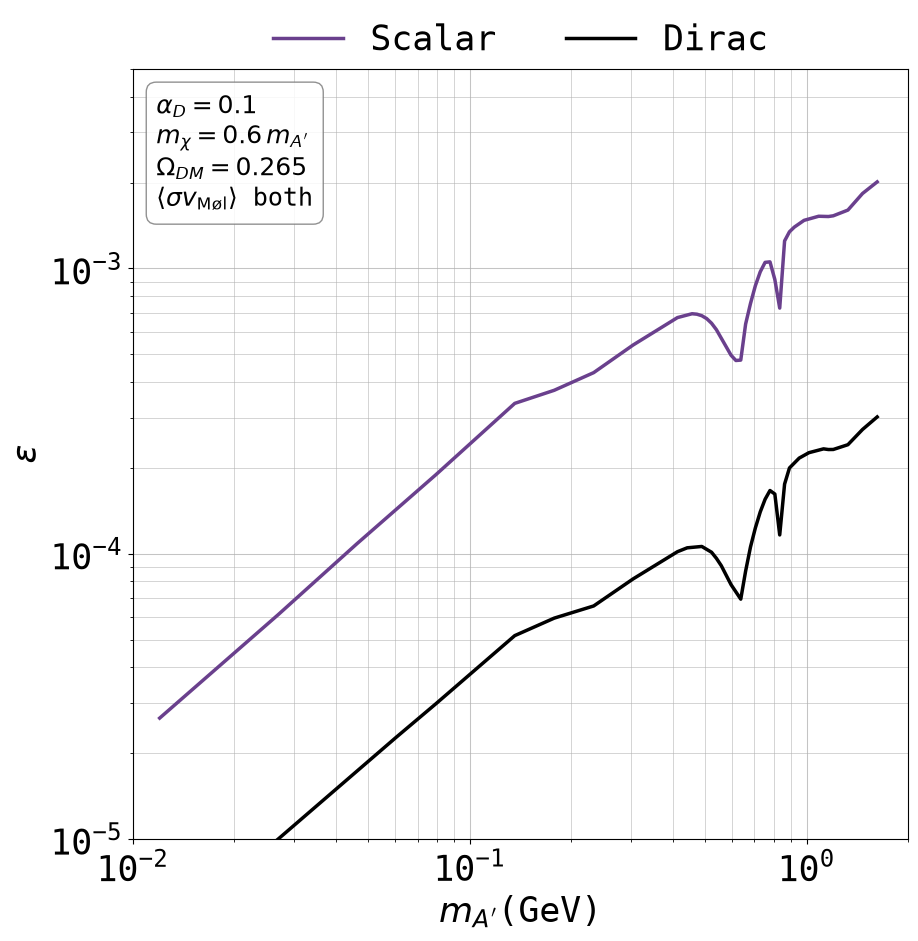

In [ ]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

# Both lines are the same Gondolo-Gelmini integral on the same mass grid, so
# the gap between them is the s-wave/p-wave difference and nothing else.
plt.plot(ma_moller, eps_gg, color = '#6a408d', linewidth = 2.5,
         label = r"Scalar")
plt.plot(ma_moller, eps_gg_dirac, color = 'black', linewidth = 2.5,
         label = r"Dirac")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % info_gg_dirac["alphaD"],
                   r"$m_\chi = %g\, m_{A'}$" % info_gg_dirac["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % info_gg_dirac["target"],
                   r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ both"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 2,                      # spread horizontally
    frameon = False                # removes legend border
)

x_min = 1e-2
x_max = 2

y_min = 1e-5
y_max = 5e-3

ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

plt.savefig("figures/relic_abundance_dirac.pdf", bbox_inches='tight')
plt.show()

### Solving Boltzmann's equation

Nothing changes from the previous case, just annihilation cross section:

In [104]:
### Boltzmann equation for the Dirac case.

# H, s and Yeq are unchanged:

def dYdxdirac(x, Y, g, vare, ma, alpha, alphaD, mpsi):
    """Dirac DM, <sigma v> from the velocity expansion."""
    return dYdxcore(x, Y, g, mpsi,
                    sigmavreldirac(vare, ma, alpha, alphaD, mpsi, x))


def omega_of_dirac(ma, vare, alphaD, mchi_over_ma=0.6,
                   xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega at one (ma, vare) point for Dirac DM."""
    mpsi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdxdirac(x, Y, GDIRAC, vare, ma, alpha, alphaD, mpsi)
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, GDIRAC, mpsi)],
                    method="Radau", rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mpsi, sol.y[0][-1])

# The Newton step in refine_eps uses LOGSLOPE, which was measured on the
# scalar model.

In [105]:
### Running the scan, same alphaD and mass ratio as the closed form above.

# The window starts a decade lower than the scalar scans:

ma_scan_dirac = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo_dirac, vare_hi_dirac = 1e-6, 2e-3

eps_relic_dirac, scan_info_dirac = scan_relic_line(
    ma_scan_dirac, vare_lo_dirac, vare_hi_dirac,
    alphaD=0.1, mchi_over_ma=0.6, omega_fun=omega_of_dirac)

In [106]:
### Closed form against Boltzmann, on the masses the scan actually solved.

ok_dirac = np.isfinite(eps_relic_dirac)
eps_closed_on_scan = eps_approx1_dirac(ma_scan_dirac[ok_dirac], alpha, 0.1,
                                       0.6*ma_scan_dirac[ok_dirac])
ratio_dirac = eps_closed_on_scan/eps_relic_dirac[ok_dirac]

# Confirm the returned epsilons really do reproduce the target, since the
# scan stops on a tolerance in log Omega rather than in eps.

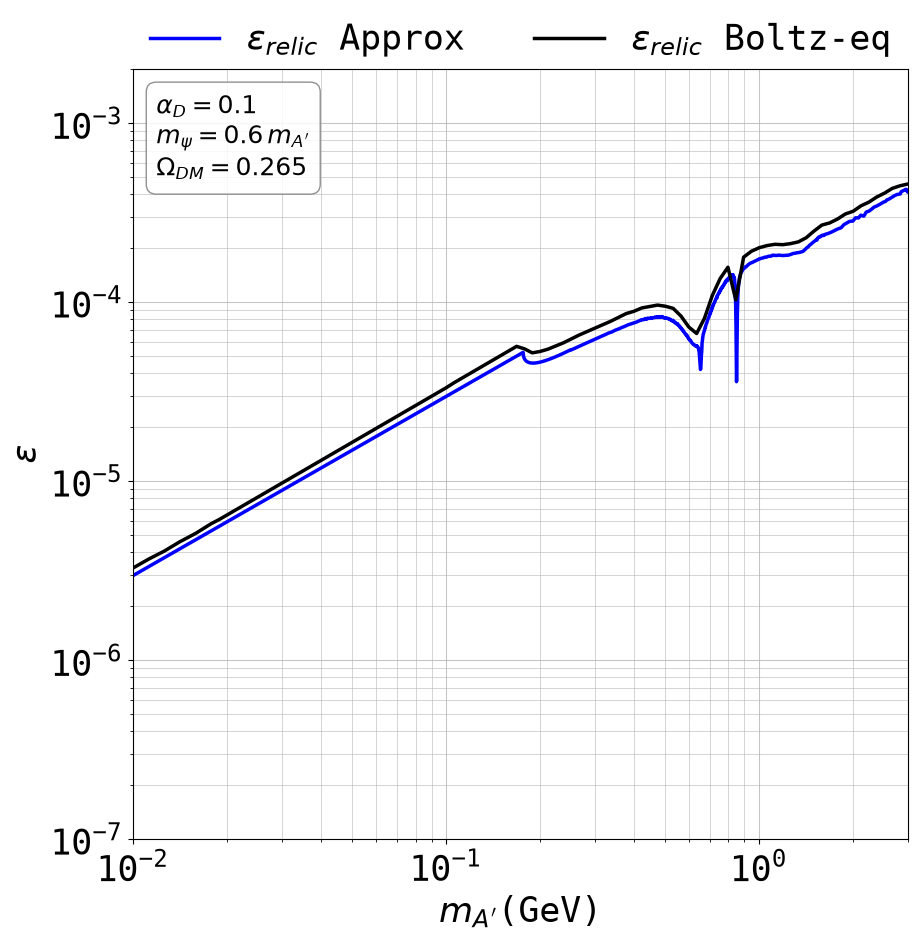

In [107]:
# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma, eps_approx_1_dirac, color = 'blue', linewidth = 2.5,
         label = r"$\varepsilon_{relic}$ Approx")

plt.plot(ma_scan_dirac, eps_relic_dirac, color = 'black', linewidth = 2.5,
         label = r"$\varepsilon_{relic}$ Boltz-eq")

# The parameters that were held fixed rather than scanned over, read back
# out of the scan info dict so the annotation cannot drift away from what
# was actually run.

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % scan_info_dirac["alphaD"],
                   r"$m_\psi = %g\, m_{A'}$" % scan_info_dirac["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info_dirac["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
#plt.savefig("figures/relic_abundance_dirac_scan_0.pdf", bbox_inches='tight')
plt.show()